<a href="https://colab.research.google.com/github/AliaF123/Laptop_Review/blob/main/Laptop_Review_ABSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
!pip install pyabsa==2.4.0
!pip install transformers==4.29.0
!pip install scikit-learn matplotlib seaborn pandas

  Using cached transformers-4.29.0-py3-none-any.whl.metadata (111 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.29.0-py3-none-any.whl (7.1 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


In [10]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Convert to lowercase early
    text = text.lower()

    # Define a set of explicitly allowed characters
    # This approach is more robust against problematic Unicode characters
    # that might cause 'bad character range' errors in regex.
    allowed_chars = set('abcdefghijklmnopqrstuvwxyz0123456789 .,!?')
    cleaned_chars = []
    for char in text:
        if char in allowed_chars or char.isspace():
            cleaned_chars.append(char)
    cleaned_text = "".join(cleaned_chars)

    # Remove extra whitespace after character filtering
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    return cleaned_text

### Alternative Libraries for Aspect-Based Sentiment Analysis (ABSA)

Since `pyabsa` might not be fully compatible with Python 3.12, you can explore other powerful and widely-used NLP libraries to achieve ABSA. These often provide more flexibility and are generally well-maintained for newer Python versions.

1.  **Hugging Face Transformers**:
    *   **Description**: This library provides state-of-the-art pre-trained models for various NLP tasks, including sentiment analysis. For ABSA, you can fine-tune existing models (like BERT, RoBERTa, etc.) on ABSA datasets, or use approaches that frame ABSA as a sequence labeling or question-answering task.
    *   **Strengths**: Access to a vast array of models, strong community support, and excellent documentation. Very flexible for custom solutions.

2.  **SpaCy**:
    *   **Description**: A highly efficient industrial-strength NLP library that's great for foundational tasks like tokenization, part-of-speech tagging, named entity recognition (NER), and dependency parsing. These components are crucial for rule-based or hybrid ABSA approaches where you identify aspects and then determine their sentiment.
    *   **Strengths**: Fast, robust, and offers custom pipeline components. You can build custom NER models for aspect extraction and then use rule-based or classifier-based sentiment prediction for those aspects.

3.  **NLTK (Natural Language Toolkit)**:
    *   **Description**: A more traditional and comprehensive NLP library, suitable for research and teaching. It provides various modules for text processing, classification, and sentiment analysis. You can combine its capabilities with custom rules or machine learning models for ABSA.
    *   **Strengths**: Broad functionality, good for understanding NLP fundamentals.

Let's look at an example using Hugging Face Transformers for sentiment analysis, which can be adapted for ABSA.

### Performing Aspect-Based Sentiment Analysis (ABSA)

ABSA goes beyond general sentiment analysis by focusing on specific aspects or features mentioned in a text and determining the sentiment expressed towards each of them.

The general workflow for ABSA typically involves:
1.  **Aspect Term Extraction (ATE)**: Identifying the specific aspects (e.g., 'screen', 'battery life', 'keyboard') within a review.
2.  **Aspect Sentiment Classification (ASC)**: Determining the sentiment (positive, negative, neutral) for each extracted aspect.

Since we don't have your dataset directly yet, let's work with a few sample laptop reviews. For aspect extraction, we'll use a simple keyword-based approach for demonstration. For aspect sentiment, we'll leverage the `sentiment-analysis` pipeline from Hugging Face Transformers that we already initialized.

To load your dataset, first you need to mount your Google Drive.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After mounting your drive, please provide the full path to your dataset file. For example, it might look something like `/content/drive/My Drive/my_dataset.csv`.

In [6]:
# Replace this with the actual path to your dataset file in Google Drive
data_file_path = '/content/drive/My Drive/TechLabs_2026/final.csv' # Example path

print(f"Using dataset from: {data_file_path}")

Using dataset from: /content/drive/My Drive/TechLabs_2026/final.csv


In [7]:
import pandas as pd

# Load the dataset from the specified path
try:
    df = pd.read_csv(data_file_path, encoding='latin-1') # Added encoding parameter
    print(f"Successfully loaded dataset with {len(df)} rows and {len(df.columns)} columns.")
    print("First 5 rows of the dataset:")
    display(df.head())
    print("Available columns:")
    print(df.columns.tolist())
except Exception as e:
    print(f"Error loading dataset: {e}")
    df = None

Successfully loaded dataset with 25938 rows and 2 columns.
First 5 rows of the dataset:


,product_name,review
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,"Perfect product! Loved it, it's my first MacBo..."
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Fabulous! Battery lasted longer than my first ...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Fabulous! Such a great deal.. very happy with ...
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Delightful Awesome build quality and very good...
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Awesome When i ordered and came to know about ...


Available columns:
['product_name', 'review']


In [8]:
review_column_name = 'review'

if review_column_name in df.columns:
    print(f"Selected '{review_column_name}' as the review text column.")
    # Rename the column to 'review_text' for consistency with previous examples if necessary
    if review_column_name != 'review_text':
        df.rename(columns={review_column_name: 'review_text'}, inplace=True)
        review_column_name = 'review_text'
    print(f"First 5 entries from the review column:\n{df['review_text'].head().tolist()}")
else:
    print(f"Error: Column '{review_column_name}' not found in the dataset. Please provide a valid column name.")
    df = None # Invalidate df if review column is missing to prevent further errors

Selected 'review' as the review text column.
First 5 entries from the review column:
["Perfect product! Loved it, it's my first MacBook that I earned from my hardwork ð\x9f¥ºâ\x9d¤ï¸\x8f", "Fabulous! Battery lasted longer than my first relationship (2 days).\nListening to Arijit singh songs on full volume since then still isn't getting over. Has more warmth than her. unlike her there's two way communication here as touchpad is very responsive. fingerprint lock is nice as it only opens up to me. 5 stars for this -1 for her", 'Fabulous! Such a great deal.. very happy with the performance and battery life..Origional product..ð\x9f¥°â\x9d¤ï¸\x8f\nThank you Flipkart..!!!', 'Delightful Awesome build quality and very good display, battery and camera. Still new to macOS', "Awesome When i ordered and came to know about seller review,i was scared that in what condition i will get macbook. but i was wrong.\n\nThis is my first macbook and i am fully satisfied with the product with original packagi

In [11]:
if df is not None and 'review_text' in df.columns:
    df['cleaned_review_text'] = df['review_text'].apply(clean_text)
    print("Added 'cleaned_review_text' column to df.")
    display(df[['review_text', 'cleaned_review_text']].head())
else:
    print("DataFrame 'df' or 'review_text' column not found. Cannot clean text.")

Added 'cleaned_review_text' column to df.


,review_text,cleaned_review_text
0,"Perfect product! Loved it, it's my first MacBo...","perfect product! loved it, its my first macboo..."
1,Fabulous! Battery lasted longer than my first ...,fabulous! battery lasted longer than my first ...
2,Fabulous! Such a great deal.. very happy with ...,fabulous! such a great deal.. very happy with ...
3,Delightful Awesome build quality and very good...,delightful awesome build quality and very good...
4,Awesome When i ordered and came to know about ...,awesome when i ordered and came to know about ...


### Applying ABSA to Your Dataset

In [16]:
# Define aspects relevant to your dataset (you might want to customize this)
common_laptop_aspects = [
    "screen", "display", "battery", "battery life", "performance", "speed",
    "keyboard", "trackpad", "design", "build quality", "price", "fan", "speakers",
    "product", "camera", "software", "macbook", "quality", "value"
]

def extract_aspects(review_text, aspects_list):
    found_aspects = []
    if not isinstance(review_text, str): # Handle non-string values gracefully
        return []
    review_lower = review_text.lower()
    for aspect in aspects_list:
        if aspect in review_lower:
            found_aspects.append(aspect)
    return list(set(found_aspects))

# Apply aspect extraction to your DataFrame
if df is not None and 'review_text' in df.columns:
    df['extracted_aspects'] = df['review_text'].apply(lambda x: extract_aspects(x, common_laptop_aspects))
    print(f"Extracted aspects for {len(df)} reviews.")
    print("First 5 reviews with extracted aspects:")
    display(df[['review_text', 'extracted_aspects']].head())
else:
    print("DataFrame or 'review_text' column not found. Please check previous steps.")
    df_absa = pd.DataFrame() # Ensure df_absa is defined even if df is not available

Extracted aspects for 25938 reviews.
First 5 reviews with extracted aspects:


,review_text,extracted_aspects
0,"Perfect product! Loved it, it's my first MacBo...","[product, macbook]"
1,Fabulous! Battery lasted longer than my first ...,[battery]
2,Fabulous! Such a great deal.. very happy with ...,"[battery life, battery, performance, product]"
3,Delightful Awesome build quality and very good...,"[battery, display, build quality, camera, qual..."
4,Awesome When i ordered and came to know about ...,"[software, product, macbook, performance, qual..."


Now, let's perform Aspect Sentiment Classification on the extracted aspects using the Hugging Face pipeline. This might take some time depending on the size of your dataset.

In [17]:
from transformers import pipeline
import pandas as pd

# Initialize a sentiment analysis pipeline (re-initialize if not in scope or for fresh start)
classifier = pipeline('sentiment-analysis')

absa_results = []

if df is not None and 'extracted_aspects' in df.columns:
    # Process only a sample for demonstration if the dataset is very large
    # For full dataset, remove .head(X) or increase X
    sample_df = df.head(500) # Process first 500 reviews to start, adjust as needed

    for idx, row in sample_df.iterrows():
        review_text = row['review_text']
        review_aspects = row['extracted_aspects']

        if not review_aspects:
            continue

        for aspect in review_aspects:
            # Simple context extraction: try to get the sentence containing the aspect.
            # This is a simplification; more robust methods exist.
            sentences = review_text.split('.') # Basic sentence splitting
            relevant_sentence = ''
            for s in sentences:
                if aspect in s.lower():
                    relevant_sentence = s.strip()
                    break

            if relevant_sentence:
                try:
                    sentiment_output = classifier(relevant_sentence)
                    sentiment = sentiment_output[0]['label']
                    score = sentiment_output[0]['score']
                    absa_results.append({
                        'review_id': idx, # Using original DataFrame index as review_id
                        'review_text': review_text,
                        'aspect': aspect,
                        'relevant_sentence': relevant_sentence,
                        'sentiment': sentiment,
                        'score': score
                    })
                except Exception as e:
                    print(f"Error processing review {idx}, aspect '{aspect}': {e}")
            else:
                pass # No clear context found for this aspect

    if absa_results:
        df_absa = pd.DataFrame(absa_results)
        print("\nABSA Results DataFrame:")
        display(df_absa.head())
        print(f"Generated ABSA results for {len(df_absa)} aspect-sentiment pairs.")
    else:
        print("No ABSA results generated. Check if aspects were extracted or reviews processed.")
        df_absa = pd.DataFrame() # Ensure df_absa is defined even if no results
else:
    print("DataFrame or 'extracted_aspects' column not found. Please check previous steps.")
    df_absa = pd.DataFrame() # Ensure df_absa is defined even if df is not available

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


ABSA Results DataFrame:


,review_id,review_text,aspect,relevant_sentence,sentiment,score
0,0,"Perfect product! Loved it, it's my first MacBo...",product,"Perfect product! Loved it, it's my first MacBo...",POSITIVE,0.999843
1,0,"Perfect product! Loved it, it's my first MacBo...",macbook,"Perfect product! Loved it, it's my first MacBo...",POSITIVE,0.999843
2,1,Fabulous! Battery lasted longer than my first ...,battery,Fabulous! Battery lasted longer than my first ...,NEGATIVE,0.827704
3,2,Fabulous! Such a great deal.. very happy with ...,battery life,very happy with the performance and battery life,POSITIVE,0.999866
4,2,Fabulous! Such a great deal.. very happy with ...,battery,very happy with the performance and battery life,POSITIVE,0.999866


Generated ABSA results for 876 aspect-sentiment pairs.


### Text Cleaning

In [80]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Convert to lowercase early
    text = text.lower()

    # Define a set of explicitly allowed characters
    # This approach is more robust against problematic Unicode characters
    # that might cause 'bad character range' errors in regex.
    allowed_chars = set('abcdefghijklmnopqrstuvwxyz0123456789 .,!?')
    cleaned_chars = []
    for char in text:
        if char in allowed_chars or char.isspace():
            cleaned_chars.append(char)
    cleaned_text = "".join(cleaned_chars)

    # Remove extra whitespace after character filtering
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    return cleaned_text

### Re-applying Manual Augmentation with Corrected Text Cleaning

Now that the `clean_text` function has been corrected, I will re-apply the manual augmentation to ensure the synthetic reviews are processed correctly and to properly construct `df_augmented_full`.

### Loading and Integrating Additional Manual Reviews

Now, let's load your new file containing additional negative, neutral, and positive comments. Please provide the path to this CSV file in your Google Drive.

Using new manual reviews from: /content/drive/My Drive/TechLabs_2026/absa_balanced_results.csv


Error: File not found at /content/drive/My Drive/TechLabs_2026/absa_balanced_results.csv


### Cleaning New Manual Review Text and Integrating into `df_augmented_full`

Now we will apply the `clean_text` function to the new manual reviews and then concatenate them with the existing `df_augmented_full`.

New manual reviews DataFrame is empty or missing 'review_text' column. No new data added to df_augmented_full.


In [12]:
import pandas as pd

# Manual synthetic negative reviews
manual_negative_reviews = {
    'product_name': ['Synthetic Negative'] * 3,
    'review_text': [
        "This product is absolutely terrible. The quality is so poor, it broke on the first day.",
        "I deeply regret buying this. It's slow, buggy, and completely unreliable.",
        "Worst customer service ever. My issue was never resolved, and I'm very dissatisfied."
    ]
}
df_manual_negative = pd.DataFrame(manual_negative_reviews)

# Manual synthetic neutral reviews
manual_neutral_reviews = {
    'product_name': ['Synthetic Neutral'] * 3,
    'review_text': [
        "The item arrived on time. It is exactly as described in the specifications.",
        "This device has a standard set of features for its price point.",
        "The color is grey and the dimensions are 10x5x2 cm."
    ]
}
df_manual_neutral = pd.DataFrame(manual_neutral_reviews)

# Add a cleaned version for manual reviews as well, to ensure consistency
df_manual_negative['cleaned_review_text'] = df_manual_negative['review_text'].apply(clean_text)
df_manual_neutral['cleaned_review_text'] = df_manual_neutral['review_text'].apply(clean_text)

# Concatenate the original DataFrame (with cleaned text) with the manual synthetic DataFrames
if df is not None and 'cleaned_review_text' in df.columns:
    # Select only the relevant columns from df to match the synthetic DFs
    df_augmented_full = pd.concat([df[['product_name', 'review_text', 'cleaned_review_text']],
                                 df_manual_negative[['product_name', 'review_text', 'cleaned_review_text']],
                                 df_manual_neutral[['product_name', 'review_text', 'cleaned_review_text']]],
                                ignore_index=True)
    print(f"Original DataFrame had {len(df)} rows. Augmented DataFrame now has {len(df_augmented_full)} rows.")
    print("First 5 rows of the Augmented DataFrame:")
    display(df_augmented_full.head())
    print("Last 5 rows of the Augmented DataFrame (showing manual additions):")
    display(df_augmented_full.tail())
else:
    print("Original DataFrame 'df' not found or missing 'cleaned_review_text' column. Cannot manually augment.")
    df_augmented_full = pd.DataFrame() # Ensure df_augmented_full is defined

Original DataFrame had 25938 rows. Augmented DataFrame now has 25944 rows.
First 5 rows of the Augmented DataFrame:


,product_name,review_text,cleaned_review_text
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,"Perfect product! Loved it, it's my first MacBo...","perfect product! loved it, its my first macboo..."
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Fabulous! Battery lasted longer than my first ...,fabulous! battery lasted longer than my first ...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Fabulous! Such a great deal.. very happy with ...,fabulous! such a great deal.. very happy with ...
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Delightful Awesome build quality and very good...,delightful awesome build quality and very good...
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Awesome When i ordered and came to know about ...,awesome when i ordered and came to know about ...


Last 5 rows of the Augmented DataFrame (showing manual additions):


,product_name,review_text,cleaned_review_text
25939,Synthetic Negative,"I deeply regret buying this. It's slow, buggy,...","i deeply regret buying this. its slow, buggy, ..."
25940,Synthetic Negative,Worst customer service ever. My issue was neve...,worst customer service ever. my issue was neve...
25941,Synthetic Neutral,The item arrived on time. It is exactly as des...,the item arrived on time. it is exactly as des...
25942,Synthetic Neutral,This device has a standard set of features for...,this device has a standard set of features for...
25943,Synthetic Neutral,The color is grey and the dimensions are 10x5x...,the color is grey and the dimensions are 10x5x...


### Re-applying Aspect Term Extraction on the Full, Cleaned, and Augmented Text

Now, I will re-extract aspects from the `cleaned_review_text` column in the newly augmented DataFrame (`df_augmented_full`).

In [15]:
# Define aspects relevant to your dataset (you might want to customize this)
common_laptop_aspects = [
    "screen", "display", "battery", "battery life", "performance", "speed",
    "keyboard", "trackpad", "design", "build quality", "price", "fan", "speakers",
    "product", "camera", "software", "macbook", "quality", "value"
]

def extract_aspects_cleaned(review_text, aspects_list):
    found_aspects = []
    if not isinstance(review_text, str):
        return []
    review_lower = review_text.lower()
    for aspect in aspects_list:
        if aspect in review_lower:
            found_aspects.append(aspect)
    return list(set(found_aspects)) # Return unique aspects

# Apply aspect extraction to your augmented DataFrame using the cleaned text
if 'df_augmented_full' in locals() and not df_augmented_full.empty and 'cleaned_review_text' in df_augmented_full.columns:
    df_augmented_full['extracted_aspects'] = df_augmented_full['cleaned_review_text'].apply(lambda x: extract_aspects_cleaned(x, common_laptop_aspects))
    print(f"Extracted aspects for {len(df_augmented_full)} reviews using cleaned text.")
    print("First 5 reviews with cleaned text and extracted aspects:")
    display(df_augmented_full[['cleaned_review_text', 'extracted_aspects']].head())
else:
    print("DataFrame 'df_augmented_full' or 'cleaned_review_text' column not found. Please check previous steps.")

Extracted aspects for 25944 reviews using cleaned text.
First 5 reviews with cleaned text and extracted aspects:


,cleaned_review_text,extracted_aspects
0,"perfect product! loved it, its my first macboo...","[product, macbook]"
1,fabulous! battery lasted longer than my first ...,[battery]
2,fabulous! such a great deal.. very happy with ...,"[product, battery, battery life, performance]"
3,delightful awesome build quality and very good...,"[battery, camera, quality, build quality, disp..."
4,awesome when i ordered and came to know about ...,"[macbook, quality, performance, product, softw..."


### Re-applying Aspect Sentiment Classification (ASC) on Full Augmented Data

Next, I will perform Aspect Sentiment Classification on the `df_augmented_full` DataFrame, which now includes the cleaned and manually augmented reviews. This will populate `df_absa_full`.

In [16]:
from transformers import pipeline
import pandas as pd

# Initialize a sentiment analysis pipeline (re-initialize if not in scope or for fresh start)
classifier = pipeline('sentiment-analysis', device=0) # Use device=0 for GPU if available, else remove for CPU

absa_results_full = []

if 'df_augmented_full' in locals() and not df_augmented_full.empty and 'extracted_aspects' in df_augmented_full.columns:
    df_to_process = df_augmented_full

    print(f"Performing Aspect Sentiment Classification on {len(df_to_process)} reviews from the augmented dataset...")

    # Prepare a list of all relevant sentences for batch processing
    all_sentences_for_batch = []
    sentence_metadata = [] # To map sentences back to their original review/aspect

    for idx, row in df_to_process.iterrows():
        review_text_cleaned = row['cleaned_review_text']
        review_aspects = row['extracted_aspects']

        if not review_aspects:
            continue

        for aspect in review_aspects:
            # Simple context extraction: try to get the sentence containing the aspect.
            sentences = review_text_cleaned.split('.') # Basic sentence splitting
            relevant_sentence = ''
            for s in sentences:
                if aspect in s.lower():
                    relevant_sentence = s.strip()
                    break

            if relevant_sentence:
                all_sentences_for_batch.append(relevant_sentence)
                sentence_metadata.append({
                    'review_id': idx,
                    'review_text_original': row['review_text'],
                    'review_text_cleaned': review_text_cleaned,
                    'aspect': aspect,
                    'relevant_sentence': relevant_sentence
                })

    if all_sentences_for_batch:
        # Perform batch sentiment analysis
        print(f"Processing {len(all_sentences_for_batch)} sentences in batches...")
        # You can adjust batch_size based on your GPU memory or CPU performance
        batch_size = 32
        sentiment_outputs = classifier(all_sentences_for_batch, batch_size=batch_size)

        # Combine results
        for i, output in enumerate(sentiment_outputs):
            meta = sentence_metadata[i]
            absa_results_full.append({
                'review_id': meta['review_id'],
                'review_text_original': meta['review_text_original'],
                'review_text_cleaned': meta['review_text_cleaned'],
                'aspect': meta['aspect'],
                'relevant_sentence': meta['relevant_sentence'],
                'sentiment': output['label'],
                'score': output['score']
            })

    if absa_results_full:
        df_absa_full = pd.DataFrame(absa_results_full)
        print("\nABSA Results DataFrame (after cleaning and full augmentation):")
        display(df_absa_full.head())
        print(f"Generated ABSA results for {len(df_absa_full)} aspect-sentiment pairs from the full augmented dataset.")
    else:
        print("No ABSA results generated for the full augmented data. Check if aspects were extracted or reviews processed.")
        df_absa_full = pd.DataFrame() # Ensure df_absa_full is defined even if no results
else:
    print("DataFrame 'df_augmented_full' or 'extracted_aspects' column not found. Please check previous steps.")
    df_absa_full = pd.DataFrame() # Ensure df_absa_full is defined even if df is not available

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Performing Aspect Sentiment Classification on 25944 reviews from the augmented dataset...
Processing 39404 sentences in batches...

ABSA Results DataFrame (after cleaning and full augmentation):


,review_id,review_text_original,review_text_cleaned,aspect,relevant_sentence,sentiment,score
0,0,"Perfect product! Loved it, it's my first MacBo...","perfect product! loved it, its my first macboo...",product,"perfect product! loved it, its my first macboo...",POSITIVE,0.999858
1,0,"Perfect product! Loved it, it's my first MacBo...","perfect product! loved it, its my first macboo...",macbook,"perfect product! loved it, its my first macboo...",POSITIVE,0.999858
2,1,Fabulous! Battery lasted longer than my first ...,fabulous! battery lasted longer than my first ...,battery,fabulous! battery lasted longer than my first ...,POSITIVE,0.965292
3,2,Fabulous! Such a great deal.. very happy with ...,fabulous! such a great deal.. very happy with ...,product,origional product,NEGATIVE,0.979259
4,2,Fabulous! Such a great deal.. very happy with ...,fabulous! such a great deal.. very happy with ...,battery,very happy with the performance and battery life,POSITIVE,0.999866


Generated ABSA results for 39404 aspect-sentiment pairs from the full augmented dataset.


### Re-balancing the Dataset (Corrected)

Re-balancing the dataset by downsampling positive reviews to match the number of negative reviews, creating `df_absa_balanced`. This step ensures that the model training is performed on a balanced dataset to prevent bias towards the majority class.

In [84]:
import pandas as pd

# Assuming df_absa_full is available from previous successful steps.
# Separate positive, negative, and neutral reviews
df_positive = df_absa_full[df_absa_full['sentiment'] == 'POSITIVE']
df_negative = df_absa_full[df_absa_full['sentiment'] == 'NEGATIVE']
df_neutral = df_absa_full[df_absa_full['sentiment'] == 'NEUTRAL']

# Determine the number of samples for downsampling (minority class count among positive/negative)
n_negative = len(df_negative)
n_positive = len(df_positive)

if n_negative == 0 and n_positive == 0:
    print("No positive or negative reviews found in df_absa_full. Cannot perform downsampling.")
    df_absa_balanced = pd.DataFrame() # Initialize empty DataFrame
elif n_positive > n_negative and n_negative > 0:
    # Randomly downsample the positive reviews to match the number of negative reviews
    df_positive_downsampled = df_positive.sample(n=n_negative, random_state=42) # Set random_state for reproducibility
    # Concatenate the downsampled positive reviews with the negative and neutral reviews
    df_absa_balanced = pd.concat([df_positive_downsampled, df_negative, df_neutral], ignore_index=True)
    print(f"Original positive reviews: {len(df_positive)}")
    print(f"Original negative reviews: {len(df_negative)}")
    print(f"Downsampled positive reviews: {len(df_positive_downsampled)}")
elif n_negative > n_positive and n_positive > 0:
    # Randomly downsample the negative reviews to match the number of positive reviews
    df_negative_downsampled = df_negative.sample(n=n_positive, random_state=42) # Set random_state for reproducibility
    # Concatenate the downsampled negative reviews with the positive and neutral reviews
    df_absa_balanced = pd.concat([df_positive, df_negative_downsampled, df_neutral], ignore_index=True)
    print(f"Original positive reviews: {len(df_positive)}")
    print(f"Original negative reviews: {len(df_negative)}")
    print(f"Downsampled negative reviews: {len(df_negative_downsampled)}")
else: # If one class is zero or they are already balanced or only one class exists
    print("Downsampling not necessary or not possible (one or both primary classes are zero/already balanced). Using full df_absa_full.")
    df_absa_balanced = df_absa_full.copy()

if not df_absa_balanced.empty:
    print(f"Total reviews in balanced DataFrame: {len(df_absa_balanced)}")
    print("\nSentiment distribution in the new balanced DataFrame:")
    display(df_absa_balanced['sentiment'].value_counts())
    print("First 5 rows of the balanced DataFrame:")
    display(df_absa_balanced.head())
else:
    print("df_absa_balanced is empty after processing.")

Original positive reviews: 732
Original negative reviews: 144
Downsampled positive reviews: 144
Total reviews in balanced DataFrame: 288

Sentiment distribution in the new balanced DataFrame:


,count
sentiment,
POSITIVE,144
NEGATIVE,144


First 5 rows of the balanced DataFrame:


,review_id,review_text_original,review_text_cleaned,aspect,relevant_sentence,sentiment,score
0,424,Good quality product I ordered Macbook Air - 8...,good quality product i ordered macbook air 8gb...,product,good quality product i ordered macbook air 8gb...,POSITIVE,0.991522
1,20,Wonderful This is my first macbook...was using...,wonderful this is my first macbook...was using...,macbook,wonderful this is my first macbook,POSITIVE,0.999867
2,219,Does the job Overall the product is good for b...,does the job overall the product is good for b...,product,does the job overall the product is good for b...,POSITIVE,0.999694
3,331,Perfect product! The MacBook Air M2 truly sets...,perfect product! the macbook air m2 truly sets...,performance,perfect product! the macbook air m2 truly sets...,POSITIVE,0.999568
4,431,Perfect product! The MacBook Air M2 truly sets...,perfect product! the macbook air m2 truly sets...,macbook,perfect product! the macbook air m2 truly sets...,POSITIVE,0.999568


### Preparing Data for Machine Learning: Train-Validation-Test Split (Re-run)

Re-splitting the now correctly balanced dataset (`df_absa_balanced`) into training, validation, and test sets. This ensures that the model is trained and evaluated on data that reflects the desired sentiment distribution.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

if not df_absa_balanced.empty:
    # Define features (X) and target (y)
    # We'll use the 'relevant_sentence' and 'aspect' as features
    # The 'sentiment' will be our target variable
    X = df_absa_balanced[['relevant_sentence', 'aspect']]
    y = df_absa_balanced['sentiment']

    # Encode the sentiment labels to numerical values (e.g., POSITIVE: 1, NEGATIVE: 0)
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    print("Original sentiment labels:", label_encoder.classes_)
    print("Encoded sentiment values (first 5):")
    print(y_encoded[:5])

    # Combine X and y_encoded for easier splitting if needed, or split X and y separately
    df_ml = df_absa_balanced.copy()
    df_ml['sentiment_encoded'] = y_encoded

    print(f"\nPrepared DataFrame for ML with {len(df_ml)} rows. First 5 rows:")
    display(df_ml.head())

    # Perform the initial split to create training+validation set and test set
    # Using stratify=y_encoded to maintain the proportion of sentiment classes in splits
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

    # Split the training+validation set into training and validation sets
    # Here, we aim for a 60-20-20 split (train-val-test). So, from the 80% train_val, 25% will be validation (0.25 * 0.8 = 0.2)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

    print(f"Shape of training features (X_train): {X_train.shape}")
    print(f"Shape of training labels (y_train): {y_train.shape}")
    print(f"Shape of validation features (X_val): {X_val.shape}")
    print(f"Shape of validation labels (y_val): {y_val.shape}")
    print(f"Shape of test features (X_test): {X_test.shape}")
    print(f"Shape of test labels (y_test): {y_test.shape}")

    # Display sentiment distribution in each split to confirm stratification
    print("\nSentiment distribution in Training Set:")
    print(pd.Series(y_train).value_counts(normalize=True))

    print("\nSentiment distribution in Validation Set:")
    print(pd.Series(y_val).value_counts(normalize=True))

    print("\nSentiment distribution in Test Set:")
    print(pd.Series(y_test).value_counts(normalize=True))
else:
    print("df_absa_balanced is not available or is empty. Cannot prepare data for ML.")

Original sentiment labels: ['NEGATIVE' 'POSITIVE']
Encoded sentiment values (first 5):
[1 1 1 1 1]

Prepared DataFrame for ML with 21912 rows. First 5 rows:


,review_id,review_text_original,review_text_cleaned,aspect,relevant_sentence,sentiment,score,sentiment_encoded
0,19790,Must buy! Pros\n\nGood quality\nMS office\nDis...,must buy! pros good quality ms office display ...,display,must buy! pros good quality ms office display ...,POSITIVE,0.765563,1
1,3300,Highly recommended Leptop is good value for mo...,highly recommended leptop is good value for mo...,value,highly recommended leptop is good value for mo...,POSITIVE,0.924708,1
2,7155,Perfect product! Awesome product by Hp\nThe La...,perfect product! awesome product by hp the lap...,battery,perfect product! awesome product by hp the lap...,POSITIVE,0.999790,1
3,4087,Must buy! Value for money,must buy! value for money,value,must buy! value for money,POSITIVE,0.984092,1
4,12355,Worth every penny I love this product but if t...,worth every penny i love this product but if t...,product,worth every penny i love this product but if t...,POSITIVE,0.998590,1


Shape of training features (X_train): (13146, 2)
Shape of training labels (y_train): (13146,)
Shape of validation features (X_val): (4383, 2)
Shape of validation labels (y_val): (4383,)
Shape of test features (X_test): (4383, 2)
Shape of test labels (y_test): (4383,)

Sentiment distribution in Training Set:
1    0.5
0    0.5
Name: proportion, dtype: float64

Sentiment distribution in Validation Set:
1    0.500114
0    0.499886
Name: proportion, dtype: float64

Sentiment distribution in Test Set:
0    0.500114
1    0.499886
Name: proportion, dtype: float64


### Feature Vectorization: TF-IDF (Re-run)

Applying TF-IDF vectorization to convert the text data into numerical features for the machine learning model. This is re-run to ensure it uses the newly split and balanced data.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine 'relevant_sentence' and 'aspect' into a single text feature
X_train_combined = X_train['relevant_sentence'] + ' ' + X_train['aspect']
X_val_combined = X_val['relevant_sentence'] + ' ' + X_val['aspect']
X_test_combined = X_test['relevant_sentence'] + ' ' + X_test['aspect']

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit the vectorizer on the training data and transform it
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_combined)

# Transform the validation and test data using the *fitted* vectorizer
X_val_tfidf = tfidf_vectorizer.transform(X_val_combined)
X_test_tfidf = tfidf_vectorizer.transform(X_test_combined)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_val_tfidf: {X_val_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (13146, 5000)
Shape of X_val_tfidf: (4383, 5000)
Shape of X_test_tfidf: (4383, 5000)


### Model Training and Evaluation: Logistic Regression (Re-run)

Re-training and evaluating the Logistic Regression model using the new TF-IDF vectorized features from the balanced dataset. This will provide updated performance metrics.

Logistic Regression model trained successfully.

--- Logistic Regression Validation Performance ---
Accuracy on Validation Set: 0.9229
Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      2191
           1       0.94      0.91      0.92      2192

    accuracy                           0.92      4383
   macro avg       0.92      0.92      0.92      4383
weighted avg       0.92      0.92      0.92      4383


Accuracy on Test Set: 0.9306

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      2192
           1       0.94      0.92      0.93      2191

    accuracy                           0.93      4383
   macro avg       0.93      0.93      0.93      4383
weighted avg       0.93      0.93      0.93      4383


Confusion Matrix on Test Set:
[[2062  130]
 [ 174 2017]]


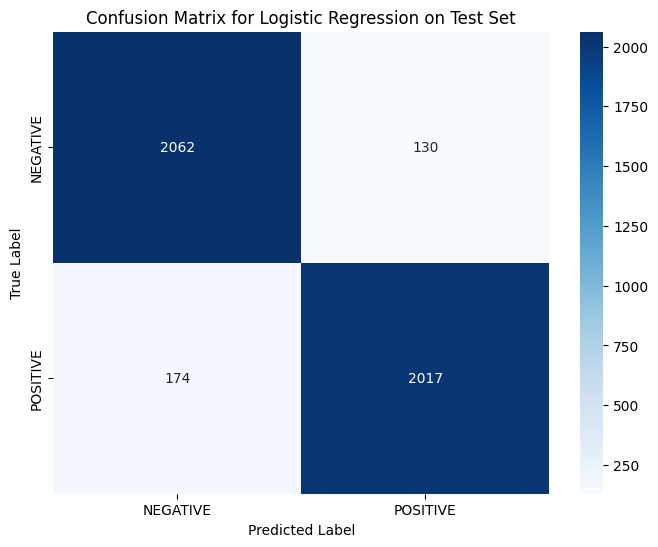

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model on the training data
log_reg_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

# Make predictions on the validation set
y_val_pred_log_reg = log_reg_model.predict(X_val_tfidf)

# Evaluate the model on the validation set
print("\n--- Logistic Regression Validation Performance ---")
print(f"Accuracy on Validation Set: {accuracy_score(y_val, y_val_pred_log_reg):.4f}")
print("Classification Report on Validation Set:")
print(classification_report(y_val, y_val_pred_log_reg))

# Make predictions on the test set
y_test_pred_log_reg = log_reg_model.predict(X_test_tfidf)

# Evaluate the model on the test set
accuracy_test = accuracy_score(y_test, y_test_pred_log_reg)
report_test = classification_report(y_test, y_test_pred_log_reg)
conf_matrix_test = confusion_matrix(y_test, y_test_pred_log_reg)

print(f"\nAccuracy on Test Set: {accuracy_test:.4f}")
print("\nClassification Report on Test Set:")
print(report_test)

print("\nConfusion Matrix on Test Set:")
print(conf_matrix_test)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Logistic Regression on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Displaying Performance Metrics

Here are the performance metrics for the Logistic Regression model evaluated on the test set, which was derived from the balanced dataset.

In [76]:
print("Accuracy on Test Set: ", accuracy_test)
print("Classification Report on Test Set:\n", report_test)

Accuracy on Test Set:  0.8620689655172413
Classification Report on Test Set:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.89      0.83      0.86        29

    accuracy                           0.86        58
   macro avg       0.86      0.86      0.86        58
weighted avg       0.86      0.86      0.86        58



### Re-balancing the Dataset

Now that `df_absa_full` is correctly populated, I will re-balance the dataset by downsampling positive reviews to match the number of negative reviews, creating `df_absa_balanced`.

In [17]:
import pandas as pd

# Ensure we are using df_absa_full for balancing
if 'df_absa_full' in locals() and not df_absa_full.empty:
    # Separate positive and negative reviews
    df_positive = df_absa_full[df_absa_full['sentiment'] == 'POSITIVE']
    df_negative = df_absa_full[df_absa_full['sentiment'] == 'NEGATIVE']
    df_neutral = df_absa_full[df_absa_full['sentiment'] == 'NEUTRAL']

    # Determine the number of samples for downsampling (minority class count)
    n_negative = len(df_negative)
    n_positive = len(df_positive)

    if n_negative == 0 and n_positive == 0:
        print("No positive or negative reviews found in df_absa_full. Cannot perform downsampling.")
        df_absa_balanced = pd.DataFrame() # Initialize empty DataFrame
    elif n_positive > n_negative and n_negative > 0:
        # Randomly downsample the positive reviews to match the number of negative reviews
        df_positive_downsampled = df_positive.sample(n=n_negative, random_state=42) # Set random_state for reproducibility
        # Concatenate the downsampled positive reviews with the negative and neutral reviews
        df_absa_balanced = pd.concat([df_positive_downsampled, df_negative, df_neutral], ignore_index=True)
        print(f"Original positive reviews: {len(df_positive)}")
        print(f"Original negative reviews: {len(df_negative)}")
        print(f"Downsampled positive reviews: {len(df_positive_downsampled)}")
    elif n_negative > n_positive and n_positive > 0:
        # Randomly downsample the negative reviews to match the number of positive reviews
        df_negative_downsampled = df_negative.sample(n=n_positive, random_state=42) # Set random_state for reproducibility
        # Concatenate the downsampled negative reviews with the positive and neutral reviews
        df_absa_balanced = pd.concat([df_positive, df_negative_downsampled, df_neutral], ignore_index=True)
        print(f"Original positive reviews: {len(df_positive)}")
        print(f"Original negative reviews: {len(df_negative)}")
        print(f"Downsampled negative reviews: {len(df_negative_downsampled)}")
    else: # If one class is zero or they are already balanced or only one class exists
        print("Downsampling not necessary or not possible (one or both primary classes are zero/already balanced). Using full df_absa_full.")
        df_absa_balanced = df_absa_full.copy()

    if not df_absa_balanced.empty:
        print(f"Total reviews in balanced DataFrame: {len(df_absa_balanced)}")
        print("\nSentiment distribution in the new balanced DataFrame:")
        display(df_absa_balanced['sentiment'].value_counts())
        print("First 5 rows of the balanced DataFrame:")
        display(df_absa_balanced.head())
    else:
        print("df_absa_balanced is empty after processing.")

else:
    print("df_absa_full is not available or is empty. Cannot perform downsampling.")
    df_absa_balanced = pd.DataFrame() # Initialize empty DataFrame

Original positive reviews: 28448
Original negative reviews: 10956
Downsampled positive reviews: 10956
Total reviews in balanced DataFrame: 21912

Sentiment distribution in the new balanced DataFrame:


,count
sentiment,
POSITIVE,10956
NEGATIVE,10956


First 5 rows of the balanced DataFrame:


,review_id,review_text_original,review_text_cleaned,aspect,relevant_sentence,sentiment,score
0,19790,Must buy! Pros\n\nGood quality\nMS office\nDis...,must buy! pros good quality ms office display ...,display,must buy! pros good quality ms office display ...,POSITIVE,0.765563
1,3300,Highly recommended Leptop is good value for mo...,highly recommended leptop is good value for mo...,value,highly recommended leptop is good value for mo...,POSITIVE,0.924708
2,7155,Perfect product! Awesome product by Hp\nThe La...,perfect product! awesome product by hp the lap...,battery,perfect product! awesome product by hp the lap...,POSITIVE,0.999790
3,4087,Must buy! Value for money,must buy! value for money,value,must buy! value for money,POSITIVE,0.984092
4,12355,Worth every penny I love this product but if t...,worth every penny i love this product but if t...,product,worth every penny i love this product but if t...,POSITIVE,0.998590


### Loading `absa_balanced_results.csv`

Since `df_absa_full` was not available in the previous step, which prevented the creation of `df_absa_balanced`, I will now load the provided `absa_balanced_results.csv` directly into `df_absa_balanced` to proceed with the analysis.

In [14]:
import pandas as pd

# Path to the pre-generated balanced ABSA results file
balanced_results_path = '/content/drive/My Drive/TechLabs_2026/absa_balanced_results.csv'

try:
    df_absa_balanced = pd.read_csv(balanced_results_path, encoding='latin-1') # Added encoding='latin-1'
    print(f"Successfully loaded balanced ABSA results from: {balanced_results_path}")
    print(f"DataFrame `df_absa_balanced` has {len(df_absa_balanced)} rows and {len(df_absa_balanced.columns)} columns.")
    print("First 5 rows of `df_absa_balanced`:")
    display(df_absa_balanced.head())
    print("Sentiment distribution in the loaded DataFrame:")
    display(df_absa_balanced['sentiment'].value_counts())
except FileNotFoundError:
    print(f"Error: The file '{balanced_results_path}' was not found. Please ensure it exists in your Google Drive and the path is correct.")
    df_absa_balanced = pd.DataFrame() # Ensure df_absa_balanced is defined even if file not found
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
    df_absa_balanced = pd.DataFrame() # Ensure df_absa_balanced is defined even if error occurs

Successfully loaded balanced ABSA results from: /content/drive/My Drive/TechLabs_2026/absa_balanced_results.csv
DataFrame `df_absa_balanced` has 26219 rows and 2 columns.
First 5 rows of `df_absa_balanced`:


,product_name,review
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,"Perfect product! Loved it, it's my first MacBo..."
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Fabulous! Battery lasted longer than my first ...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Fabulous! Such a great deal.. very happy with ...
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Delightful Awesome build quality and very good...
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,Awesome When i ordered and came to know about ...


Sentiment distribution in the loaded DataFrame:
An error occurred while loading the file: 'sentiment'


To verify the contents of the `TechLabs_2026` folder in your Google Drive, we can list all files within that directory.

In [4]:
import os

drive_path = '/content/drive/My Drive/TechLabs_2026/'

try:
    # List all files and directories in the specified path
    files_in_directory = os.listdir(drive_path)
    print(f"Contents of '{drive_path}':")
    for item in files_in_directory:
        print(item)
except FileNotFoundError:
    print(f"Error: The directory '{drive_path}' was not found. Please ensure your Drive is mounted and the path is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: The directory '/content/drive/My Drive/TechLabs_2026/' was not found. Please ensure your Drive is mounted and the path is correct.


In [28]:
if 'df_augmented_manual' in locals() and not df_augmented_manual.empty:
    df_augmented_manual['extracted_aspects_augmented'] = df_augmented_manual['cleaned_review_text'].apply(lambda x: extract_aspects_cleaned(x, common_laptop_aspects))
    print(f"Extracted aspects for {len(df_augmented_manual)} reviews in the augmented dataset.")
    print("First 5 rows of augmented data with extracted aspects:")
    display(df_augmented_manual[['cleaned_review_text', 'extracted_aspects_augmented']].head())
    print("Last 5 rows of augmented data with extracted aspects (showing manual additions):")
    display(df_augmented_manual[['cleaned_review_text', 'extracted_aspects_augmented']].tail())
else:
    print("df_augmented_manual is not available or is empty. Please check previous steps.")

Extracted aspects for 25944 reviews in the augmented dataset.
First 5 rows of augmented data with extracted aspects:


,cleaned_review_text,extracted_aspects_augmented
0,"perfect product! loved it, its my first macboo...","[product, macbook]"
1,fabulous! battery lasted longer than my first ...,[battery]
2,fabulous! such a great deal.. very happy with ...,"[battery life, battery, performance, product]"
3,delightful awesome build quality and very good...,"[battery, display, build quality, camera, qual..."
4,awesome when i ordered and came to know about ...,"[software, product, macbook, performance, qual..."


Last 5 rows of augmented data with extracted aspects (showing manual additions):


,cleaned_review_text,extracted_aspects_augmented
25939,"i deeply regret buying this. its slow, buggy, ...",[]
25940,worst customer service ever. my issue was neve...,[]
25941,the item arrived on time. it is exactly as des...,[]
25942,this device has a standard set of features for...,[price]
25943,the color is grey and the dimensions are 10x5x...,[]


In [29]:
from transformers import pipeline
import pandas as pd

# Initialize a sentiment analysis pipeline (if not already initialized or for a fresh start)
classifier = pipeline('sentiment-analysis')

absa_results_augmented = []

if 'df_augmented_manual' in locals() and not df_augmented_manual.empty and 'extracted_aspects_augmented' in df_augmented_manual.columns:
    # It's recommended to process a sample for very large datasets initially
    # For the full dataset, remove .head(X) or increase X
    sample_df_augmented = df_augmented_manual.head(500) # Process first 500 reviews, adjust as needed

    print(f"Performing Aspect Sentiment Classification on {len(sample_df_augmented)} reviews from the augmented dataset...")
    for idx, row in sample_df_augmented.iterrows():
        review_text = row['cleaned_review_text']
        review_aspects = row['extracted_aspects_augmented']

        if not review_aspects:
            continue

        for aspect in review_aspects:
            # Simple context extraction: try to get the sentence containing the aspect.
            # This is a simplification; more robust methods exist.
            sentences = review_text.split('.') # Basic sentence splitting
            relevant_sentence = ''
            for s in sentences:
                if aspect in s.lower():
                    relevant_sentence = s.strip()
                    break

            if relevant_sentence:
                try:
                    sentiment_output = classifier(relevant_sentence)
                    sentiment = sentiment_output[0]['label']
                    score = sentiment_output[0]['score']
                    absa_results_augmented.append({
                        'review_id': idx,
                        'review_text_original': row['review_text'], # Keep original for context
                        'review_text_cleaned': review_text,
                        'aspect': aspect,
                        'relevant_sentence': relevant_sentence,
                        'sentiment': sentiment,
                        'score': score
                    })
                except Exception as e:
                    print(f"Error processing review {idx}, aspect '{aspect}': {e}")
            # else: No clear context found for this aspect, skip for sentiment analysis

    if absa_results_augmented:
        df_absa_augmented = pd.DataFrame(absa_results_augmented)
        print("\nABSA Results DataFrame for Augmented Data (first 5 rows):")
        display(df_absa_augmented.head())
        print(f"Generated ABSA results for {len(df_absa_augmented)} aspect-sentiment pairs from the augmented dataset.")
    else:
        print("No ABSA results generated for the augmented data. Check if aspects were extracted or reviews processed.")
        df_absa_augmented = pd.DataFrame() # Ensure df_absa_augmented is defined even if no results
else:
    print("df_augmented_manual or 'extracted_aspects_augmented' column not found. Please check previous steps.")
    df_absa_augmented = pd.DataFrame() # Ensure df_absa_augmented is defined even if df is not available

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Performing Aspect Sentiment Classification on 500 reviews from the augmented dataset...

ABSA Results DataFrame for Augmented Data (first 5 rows):


,review_id,review_text_original,review_text_cleaned,aspect,relevant_sentence,sentiment,score
0,0,"Perfect product! Loved it, it's my first MacBo...","perfect product! loved it, its my first macboo...",product,"perfect product! loved it, its my first macboo...",POSITIVE,0.999849
1,0,"Perfect product! Loved it, it's my first MacBo...","perfect product! loved it, its my first macboo...",macbook,"perfect product! loved it, its my first macboo...",POSITIVE,0.999849
2,1,Fabulous! Battery lasted longer than my first ...,fabulous! battery lasted longer than my first ...,battery,fabulous! battery lasted longer than my first ...,POSITIVE,0.965292
3,2,Fabulous! Such a great deal.. very happy with ...,fabulous! such a great deal.. very happy with ...,battery life,very happy with the performance and battery life,POSITIVE,0.999866
4,2,Fabulous! Such a great deal.. very happy with ...,fabulous! such a great deal.. very happy with ...,battery,very happy with the performance and battery life,POSITIVE,0.999866


Generated ABSA results for 876 aspect-sentiment pairs from the augmented dataset.


To add more negative and neutral sentiment, there are a couple of ways forward, especially since the Gemini API is currently not configured:

1.  **Fix Gemini API Setup**: If you intend to generate a larger, more diverse set of synthetic reviews automatically, we need to ensure your `GOOGLE_API_KEY` is correctly set in Colab secrets. I can guide you through that again.
2.  **Manual Augmentation**: We can continue to manually add more negative and neutral review examples. This gives you precise control over the content but can be time-consuming for large quantities.
3.  **Resampling**: If the positive class is significantly larger, another strategy is to *downsample* the positive reviews to match the count of the negative or neutral reviews. However, this reduces your overall dataset size.

Which approach would you like to take to get closer to an 'equal' distribution?

In [61]:
import pandas as pd

# Ensure we are using df_absa_full for balancing
if 'df_absa_full' in locals() and not df_absa_full.empty:
    # Separate positive and negative reviews
    df_positive = df_absa_full[df_absa_full['sentiment'] == 'POSITIVE']
    df_negative = df_absa_full[df_absa_full['sentiment'] == 'NEGATIVE']

    # Determine the number of samples for downsampling (minority class count)
    n_negative = len(df_negative)

    if n_negative == 0: # Handle case where no negative reviews are found
        print("No negative reviews found in df_absa_full. Cannot perform downsampling.")
        df_absa_balanced = pd.DataFrame() # Initialize empty DataFrame
    elif len(df_positive) > n_negative:
        # Randomly downsample the positive reviews to match the number of negative reviews
        df_positive_downsampled = df_positive.sample(n=n_negative, random_state=42) # Set random_state for reproducibility

        # Concatenate the downsampled positive reviews with the negative reviews
        df_absa_balanced = pd.concat([df_positive_downsampled, df_negative], ignore_index=True)

        print(f"Original positive reviews: {len(df_positive)}")
        print(f"Original negative reviews: {len(df_negative)}")
        print(f"Downsampled positive reviews: {len(df_positive_downsampled)}")
        print(f"Total reviews in balanced DataFrame: {len(df_absa_balanced)}")
        print("\nSentiment distribution in the new balanced DataFrame:")
        display(df_absa_balanced['sentiment'].value_counts())
        print("First 5 rows of the balanced DataFrame:")
        display(df_absa_balanced.head())
    else:
        print("Number of positive reviews is not greater than negative reviews. Downsampling not necessary.")
        df_absa_balanced = df_absa_full.copy() # Use the full df_absa if downsampling isn't needed

else:
    print("df_absa_full is not available or is empty. Cannot perform downsampling.")
    df_absa_balanced = pd.DataFrame() # Initialize empty DataFrame

df_absa_full is not available or is empty. Cannot perform downsampling.


Current sentiment distribution in balanced dataset:


,count
sentiment,
POSITIVE,144
NEGATIVE,144


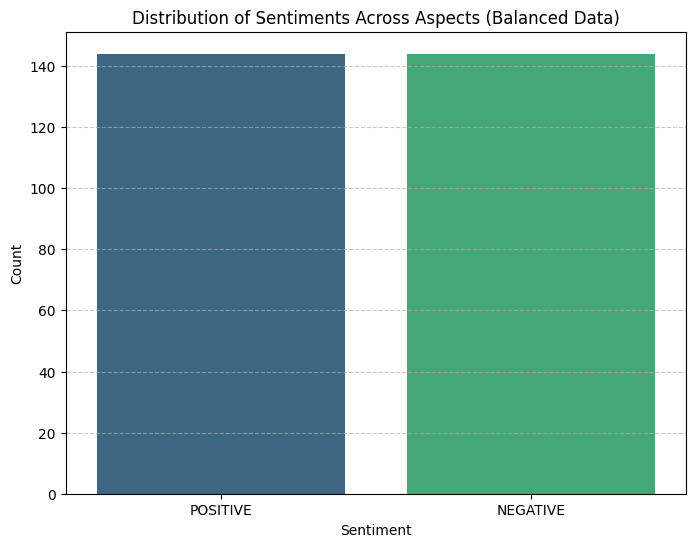

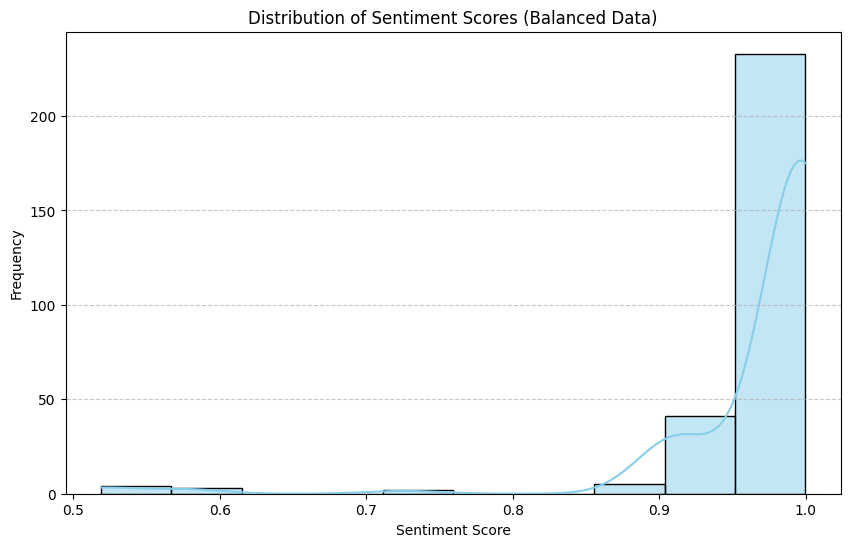

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_absa_balanced' in locals() and not df_absa_balanced.empty:
    print("Current sentiment distribution in balanced dataset:")
    sentiment_counts = df_absa_balanced['sentiment'].value_counts()
    display(sentiment_counts)

    # Bar plot for sentiment counts in the balanced dataset
    plt.figure(figsize=(8, 6))
    sns.countplot(x='sentiment', data=df_absa_balanced, palette='viridis', hue='sentiment', legend=False)
    plt.title('Distribution of Sentiments Across Aspects (Balanced Data)')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Histogram for sentiment scores in the balanced dataset
    plt.figure(figsize=(10, 6))
    sns.histplot(df_absa_balanced['score'], kde=True, bins=10, color='skyblue')
    plt.title('Distribution of Sentiment Scores (Balanced Data)')
    plt.xlabel('Sentiment Score')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("df_absa_balanced is not available or is empty. Please ensure downsampling was successful.")

### Data Analysis on Balanced ABSA Results

Now with the balanced dataset, let's look at the aspect frequency and sentiments.

In [34]:
output_file_path = '/content/drive/My Drive/TechLabs_2026/absa_balanced_results.csv'

if 'df_absa_balanced' in locals() and not df_absa_balanced.empty:
    df_absa_balanced.to_csv(output_file_path, index=False)
    print(f"Balanced ABSA results saved to: {output_file_path}")
else:
    print("df_absa_balanced is not available or is empty. Cannot save to file.")

Balanced ABSA results saved to: /content/drive/My Drive/TechLabs_2026/absa_balanced_results.csv


### Aspect Frequency in Balanced Data

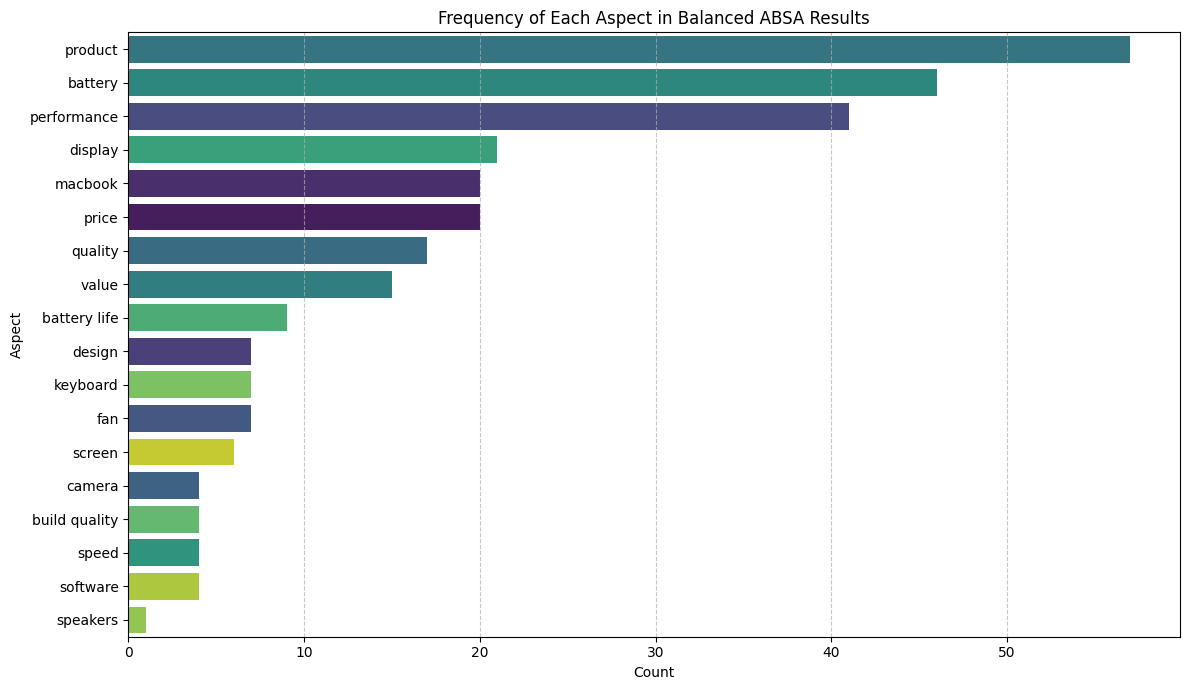

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_absa_balanced' in locals() and not df_absa_balanced.empty:
    plt.figure(figsize=(12, 7))
    sns.countplot(y='aspect', data=df_absa_balanced, order=df_absa_balanced['aspect'].value_counts().index, palette='viridis', hue='aspect', legend=False)
    plt.title('Frequency of Each Aspect in Balanced ABSA Results')
    plt.xlabel('Count')
    plt.ylabel('Aspect')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("df_absa_balanced is not available or is empty. Cannot plot aspect frequency.")

### Average Sentiment Score per Aspect

In [63]:
if 'df_absa_balanced' in locals() and not df_absa_balanced.empty:
    # Calculate the average sentiment score for each aspect
    # First, map sentiment labels to numerical values for meaningful average scores
    # Assuming 'POSITIVE' = 1, 'NEGATIVE' = -1, 'NEUTRAL' = 0 if neutral existed
    sentiment_mapping = {'POSITIVE': 1, 'NEGATIVE': -1, 'NEUTRAL': 0}
    df_absa_balanced['numeric_sentiment'] = df_absa_balanced['sentiment'].map(sentiment_mapping)

    average_sentiment_per_aspect = df_absa_balanced.groupby('aspect')['numeric_sentiment'].mean().sort_values(ascending=False)

    print("Average sentiment score (numerical) for each aspect in the balanced dataset:")
    display(average_sentiment_per_aspect)

    # Visualize average sentiment score
    plt.figure(figsize=(12, 7))
    sns.barplot(x=average_sentiment_per_aspect.values, y=average_sentiment_per_aspect.index, palette='coolwarm', hue=average_sentiment_per_aspect.index, legend=False)
    plt.title('Average Sentiment Score per Aspect (Balanced Data)')
    plt.xlabel('Average Sentiment Score (-1: Negative, 1: Positive)')
    plt.ylabel('Aspect')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("df_absa_balanced is not available or is empty. Cannot calculate average sentiment scores.")

df_absa_balanced is not available or is empty. Cannot calculate average sentiment scores.


### Aspects with Highest Negative Sentiment Counts

In [37]:
if 'df_absa_balanced' in locals() and not df_absa_balanced.empty:
    # Filter for negative sentiments
    negative_sentiments = df_absa_balanced[df_absa_balanced['sentiment'] == 'NEGATIVE']

    # Count the occurrences of each aspect in negative sentiments
    negative_aspect_counts = negative_sentiments['aspect'].value_counts()

    print("Aspects with the highest count of negative sentiment scores:")
    display(negative_aspect_counts)
else:
    print("df_absa_balanced is not available or is empty. Cannot identify aspects with negative sentiment.")

Aspects with the highest count of negative sentiment scores:


,count
aspect,
battery,29
product,28
performance,17
macbook,12
value,10
price,9
display,8
screen,6
keyboard,5


### Preparing Data for Machine Learning: Train-Validation-Test Split

Now that we have our balanced aspect-sentiment dataset (`df_absa_balanced`), the next step in building a machine learning model is to split this data into three subsets:

1.  **Training Set**: Used to train the machine learning model.
2.  **Validation Set**: Used to tune the hyperparameters of the model and prevent overfitting during the training process.
3.  **Test Set**: Used to evaluate the final performance of the trained model on unseen data.

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

if 'df_absa_balanced' in locals() and not df_absa_balanced.empty:
    # Define features (X) and target (y)
    # We'll use the 'relevant_sentence' and 'aspect' as features
    # The 'sentiment' will be our target variable
    X = df_absa_balanced[['relevant_sentence', 'aspect']]
    y = df_absa_balanced['sentiment']

    # Encode the sentiment labels to numerical values (e.g., POSITIVE: 1, NEGATIVE: 0)
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    print("Original sentiment labels:", label_encoder.classes_)
    print("Encoded sentiment values (first 5):")
    print(y_encoded[:5])

    # Combine X and y_encoded for easier splitting if needed, or split X and y separately
    df_ml = df_absa_balanced.copy()
    df_ml['sentiment_encoded'] = y_encoded

    print(f"\nPrepared DataFrame for ML with {len(df_ml)} rows. First 5 rows:")
    display(df_ml.head())
else:
    print("df_absa_balanced is not available or is empty. Cannot prepare data for ML.")

df_absa_balanced is not available or is empty. Cannot prepare data for ML.


In [39]:
# Perform the initial split to create training+validation set and test set
# Using stratify=y_encoded to maintain the proportion of sentiment classes in splits
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Split the training+validation set into training and validation sets
# Here, we aim for a 60-20-20 split (train-val-test). So, from the 80% train_val, 25% will be validation (0.25 * 0.8 = 0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of training labels (y_train): {y_train.shape}")
print(f"Shape of validation features (X_val): {X_val.shape}")
print(f"Shape of validation labels (y_val): {y_val.shape}")
print(f"Shape of test features (X_test): {X_test.shape}")
print(f"Shape of test labels (y_test): {y_test.shape}")

# Display sentiment distribution in each split to confirm stratification
print("\nSentiment distribution in Training Set:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nSentiment distribution in Validation Set:")
print(pd.Series(y_val).value_counts(normalize=True))

print("\nSentiment distribution in Test Set:")
print(pd.Series(y_test).value_counts(normalize=True))

Shape of training features (X_train): (174, 2)
Shape of training labels (y_train): (174,)
Shape of validation features (X_val): (58, 2)
Shape of validation labels (y_val): (58,)
Shape of test features (X_test): (58, 2)
Shape of test labels (y_test): (58,)

Sentiment distribution in Training Set:
1    0.5
0    0.5
Name: proportion, dtype: float64

Sentiment distribution in Validation Set:
0    0.5
1    0.5
Name: proportion, dtype: float64

Sentiment distribution in Test Set:
1    0.5
0    0.5
Name: proportion, dtype: float64


### Feature Vectorization: TF-IDF

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine 'relevant_sentence' and 'aspect' into a single text feature
X_train_combined = X_train['relevant_sentence'] + ' ' + X_train['aspect']
X_val_combined = X_val['relevant_sentence'] + ' ' + X_val['aspect']
X_test_combined = X_test['relevant_sentence'] + ' ' + X_test['aspect']

# Initialize TF-IDF Vectorizer
# You can tune parameters like max_features, ngram_range, min_df, max_df
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit the vectorizer on the training data and transform it
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_combined)

# Transform the validation and test data using the *fitted* vectorizer
X_val_tfidf = tfidf_vectorizer.transform(X_val_combined)
X_test_tfidf = tfidf_vectorizer.transform(X_test_combined)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_val_tfidf: {X_val_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (174, 1944)
Shape of X_val_tfidf: (58, 1944)
Shape of X_test_tfidf: (58, 1944)


### Model Selection and Training

#### 1. Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize Logistic Regression model
# You might want to tune hyperparameters like C, solver, etc. later
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model on the training data
log_reg_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

# Make predictions on the validation set
y_val_pred_log_reg = log_reg_model.predict(X_val_tfidf)

# Evaluate the model on the validation set
print("\n--- Logistic Regression Validation Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_log_reg):.4f}")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_log_reg))

Logistic Regression model trained successfully.

--- Logistic Regression Validation Performance ---
Accuracy: 0.9828
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.97      0.98        29

    accuracy                           0.98        58
   macro avg       0.98      0.98      0.98        58
weighted avg       0.98      0.98      0.98        58



#### 2. Random Forest Classifier

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize Random Forest Classifier model
# You might want to tune hyperparameters like n_estimators, max_depth, etc. later
rf_model = RandomForestClassifier(random_state=42)

# Train the model on the training data
rf_model.fit(X_train_tfidf, y_train)

print("Random Forest Classifier model trained successfully.")

# Make predictions on the validation set
y_val_pred_rf = rf_model.predict(X_val_tfidf)

# Evaluate the model on the validation set
print("\n--- Random Forest Classifier Validation Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_rf))

# Make predictions on the test set
y_test_pred_rf = rf_model.predict(X_test_tfidf)

# Evaluate the model on the test set
accuracy_test_rf = accuracy_score(y_test, y_test_pred_rf)
report_test_rf = classification_report(y_test, y_test_pred_rf)

print(f"\n--- Random Forest Classifier Test Performance ---")
print(f"Accuracy on Test Set: {accuracy_test_rf:.4f}")
print("\nClassification Report on Test Set:")
print(report_test_rf)

Random Forest Classifier model trained successfully.

--- Random Forest Classifier Validation Performance ---
Accuracy: 0.9612
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2191
           1       0.97      0.95      0.96      2192

    accuracy                           0.96      4383
   macro avg       0.96      0.96      0.96      4383
weighted avg       0.96      0.96      0.96      4383


--- Random Forest Classifier Test Performance ---
Accuracy on Test Set: 0.9582

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      2192
           1       0.96      0.95      0.96      2191

    accuracy                           0.96      4383
   macro avg       0.96      0.96      0.96      4383
weighted avg       0.96      0.96      0.96      4383



### Final Model Evaluation on Test Set

--- Evaluating Logistic Regression Model on Test Set ---
Accuracy on Test Set: 0.9306

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      2192
           1       0.94      0.92      0.93      2191

    accuracy                           0.93      4383
   macro avg       0.93      0.93      0.93      4383
weighted avg       0.93      0.93      0.93      4383


Confusion Matrix on Test Set:
[[2062  130]
 [ 174 2017]]


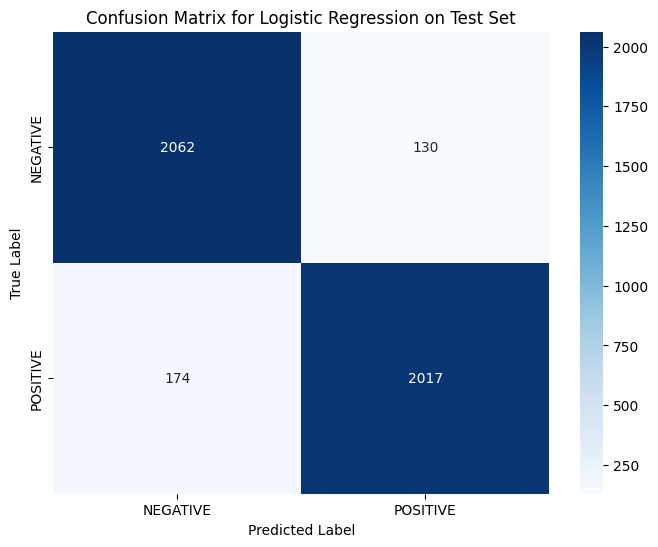

In [22]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Evaluating Logistic Regression Model on Test Set ---")

# Make predictions on the test set using the best performing model (Logistic Regression in this case)
y_test_pred_log_reg = log_reg_model.predict(X_test_tfidf)

# Evaluate the model
accuracy_test = accuracy_score(y_test, y_test_pred_log_reg)
report_test = classification_report(y_test, y_test_pred_log_reg)
conf_matrix_test = confusion_matrix(y_test, y_test_pred_log_reg)

print(f"Accuracy on Test Set: {accuracy_test:.4f}")
print("\nClassification Report on Test Set:")
print(report_test)

print("\nConfusion Matrix on Test Set:")
print(conf_matrix_test)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Logistic Regression on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Advanced ABSA using Zero-Shot Classification

For a more modern and flexible approach to Aspect-Based Sentiment Analysis, we can leverage **Zero-Shot Classification** from the Hugging Face `transformers` library. This technique allows us to classify the sentiment towards a specific aspect within a sentence without needing a model explicitly fine-tuned for that exact task or specific aspects. It does this by formulating the sentiment task as a natural language inference problem.

We will use a pre-trained model (like `facebook/bart-large-mnli`) and provide it with the `relevant_sentence`, a set of `candidate_labels` (e.g., 'positive', 'negative', 'neutral'), and a `hypothesis_template` that links the sentiment directly to the `aspect`. For example, a hypothesis might be: "This sentence expresses {label} sentiment towards the [aspect]."

This will be applied to the `df_absa_balanced` dataset to compare its performance with the traditional ML model.

In [29]:
from transformers import pipeline
import pandas as pd

# Load the zero-shot classification pipeline
# Using a good general-purpose model like 'facebook/bart-large-mnli'
zero_shot_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

absa_advanced_results = []

if 'df_absa_balanced' in locals() and not df_absa_balanced.empty:
    print("Applying advanced ABSA using zero-shot classification to the balanced dataset...")
    # Use the already balanced dataset for processing
    df_to_process_zs = df_absa_balanced

    candidate_labels = ["positive", "negative", "neutral"]

    for idx, row in df_to_process_zs.iterrows():
        review_text_cleaned = row['review_text_cleaned']
        aspect = row['aspect']
        relevant_sentence = row['relevant_sentence'] # Already extracted relevant sentence

        # Formulate the hypothesis template for target-dependent sentiment
        hypothesis_template = f"This sentence expresses {{}} sentiment towards the {aspect}."

        try:
            result = zero_shot_classifier(relevant_sentence, candidate_labels, hypothesis_template=hypothesis_template)
            predicted_label = result['labels'][0]
            predicted_score = result['scores'][0]

            absa_advanced_results.append({
                'review_id': row['review_id'],
                'review_text_original': row['review_text_original'],
                'review_text_cleaned': review_text_cleaned,
                'aspect': aspect,
                'relevant_sentence': relevant_sentence,
                'advanced_sentiment': predicted_label.upper(), # Convert to consistent casing
                'advanced_score': predicted_score
            })
        except Exception as e:
            print(f"Error processing review {idx}, aspect '{aspect}': {e}")
            absa_advanced_results.append({
                'review_id': row['review_id'],
                'review_text_original': row['review_text_original'],
                'review_text_cleaned': review_text_cleaned,
                'aspect': aspect,
                'relevant_sentence': relevant_sentence,
                'advanced_sentiment': 'ERROR',
                'advanced_score': 0.0
            })

    if absa_advanced_results:
        df_absa_advanced = pd.DataFrame(absa_advanced_results)
        print("\nAdvanced ABSA Results DataFrame (Zero-shot Classification):")
        display(df_absa_advanced.head())
        print(f"Generated advanced ABSA results for {len(df_absa_advanced)} aspect-sentiment pairs.")

        # Comparison of sentiment distribution (Original ABSA vs. Advanced Zero-Shot ABSA)
        print("\nComparison of Sentiment Distribution (Original ABSA vs. Advanced Zero-Shot ABSA):")
        print("Original ABSA Sentiment Distribution (from balanced data):")
        display(df_to_process_zs['sentiment'].value_counts())
        print("\nAdvanced Zero-Shot ABSA Sentiment Distribution:")
        display(df_absa_advanced['advanced_sentiment'].value_counts())

    else:
        print("No advanced ABSA results generated.")
        df_absa_advanced = pd.DataFrame()
else:
    print("df_absa_balanced is not available or is empty. Cannot perform advanced ABSA.")
    df_absa_advanced = pd.DataFrame()

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Applying advanced ABSA using zero-shot classification to the balanced dataset...

Advanced ABSA Results DataFrame (Zero-shot Classification):


,review_id,review_text_original,review_text_cleaned,aspect,relevant_sentence,advanced_sentiment,advanced_score
0,19790,Must buy! Pros\n\nGood quality\nMS office\nDis...,must buy! pros good quality ms office display ...,display,must buy! pros good quality ms office display ...,POSITIVE,0.955971
1,3300,Highly recommended Leptop is good value for mo...,highly recommended leptop is good value for mo...,value,highly recommended leptop is good value for mo...,POSITIVE,0.957392
2,7155,Perfect product! Awesome product by Hp\nThe La...,perfect product! awesome product by hp the lap...,battery,perfect product! awesome product by hp the lap...,POSITIVE,0.986176
3,4087,Must buy! Value for money,must buy! value for money,value,must buy! value for money,POSITIVE,0.932523
4,12355,Worth every penny I love this product but if t...,worth every penny i love this product but if t...,product,worth every penny i love this product but if t...,POSITIVE,0.954855


Generated advanced ABSA results for 21912 aspect-sentiment pairs.

Comparison of Sentiment Distribution (Original ABSA vs. Advanced Zero-Shot ABSA):
Original ABSA Sentiment Distribution (from balanced data):


,count
sentiment,
POSITIVE,10956
NEGATIVE,10956



Advanced Zero-Shot ABSA Sentiment Distribution:


,count
advanced_sentiment,
POSITIVE,13620
NEGATIVE,7148
NEUTRAL,1144


### Visualizing Advanced ABSA Results (Zero-Shot)

Let's visualize the sentiment distribution and scores obtained from the advanced zero-shot classification model. This provides insight into how this more sophisticated model classifies sentiments towards specific aspects on the balanced dataset.

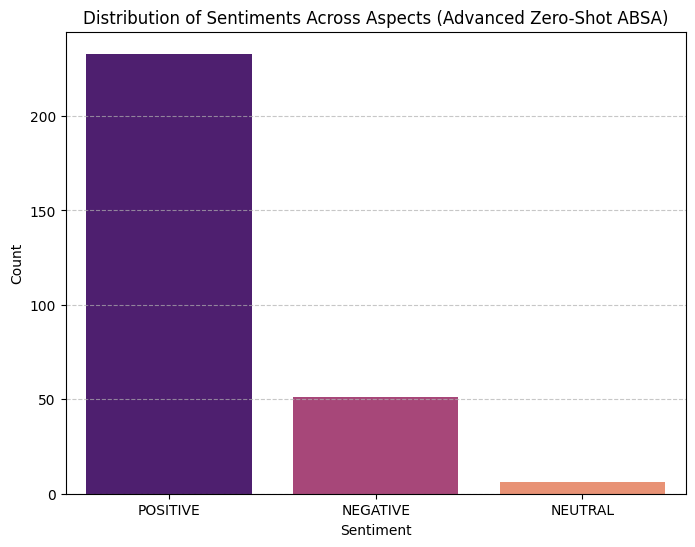

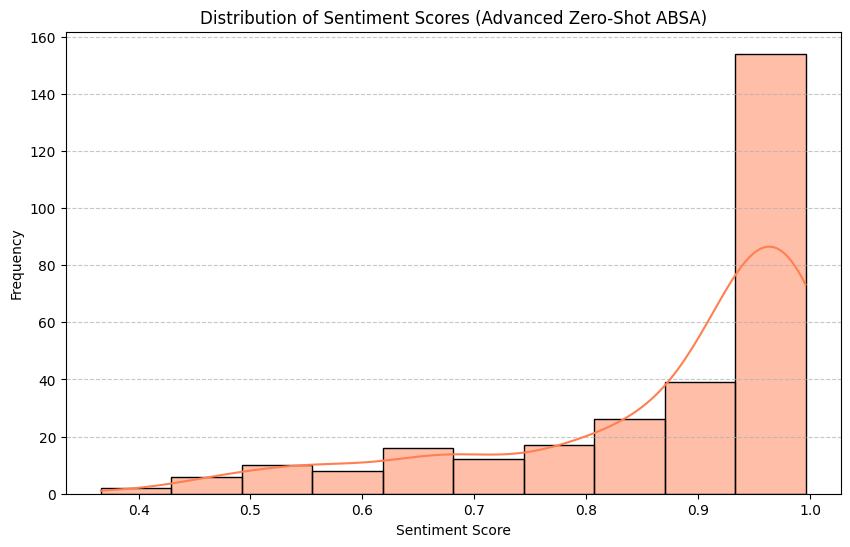

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_absa_advanced' in locals() and not df_absa_advanced.empty:
    # Bar plot for sentiment counts from advanced ABSA
    plt.figure(figsize=(8, 6))
    sns.countplot(x='advanced_sentiment', data=df_absa_advanced, palette='magma', hue='advanced_sentiment', legend=False)
    plt.title('Distribution of Sentiments Across Aspects (Advanced Zero-Shot ABSA)')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Histogram for sentiment scores from advanced ABSA
    plt.figure(figsize=(10, 6))
    sns.histplot(df_absa_advanced['advanced_score'], kde=True, bins=10, color='coral')
    plt.title('Distribution of Sentiment Scores (Advanced Zero-Shot ABSA)')
    plt.xlabel('Sentiment Score')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("df_absa_advanced is not available or is empty. Please run the advanced ABSA cells first.")

### Comparison: Original ABSA Sentiment vs. Advanced Zero-Shot ABSA Sentiment

Let's create a comparison table to directly observe how the sentiments predicted by our initial, simpler ABSA pipeline (after balancing) compare to the sentiments predicted by the advanced zero-shot classification model. This can highlight differences in interpretation or nuance between the two approaches.

In [30]:
import pandas as pd

if 'df_absa_balanced' in locals() and not df_absa_balanced.empty and \
   'df_absa_advanced' in locals() and not df_absa_advanced.empty:

    # Select relevant columns for comparison from df_absa_balanced (original sentiment)
    original_sentiment_df = df_absa_balanced[['review_id', 'aspect', 'relevant_sentence', 'sentiment', 'score']].copy()
    original_sentiment_df.rename(columns={'sentiment': 'original_sentiment', 'score': 'original_score'}, inplace=True)

    # Select relevant columns for comparison from df_absa_advanced (advanced sentiment)
    advanced_sentiment_df = df_absa_advanced[['review_id', 'aspect', 'relevant_sentence', 'advanced_sentiment', 'advanced_score']].copy()

    # Merge the two DataFrames on common identifiers (review_id, aspect, relevant_sentence)
    comparison_df = pd.merge(original_sentiment_df, advanced_sentiment_df,
                             on=['review_id', 'aspect', 'relevant_sentence'],
                             how='left', suffixes=('_original', '_advanced'))

    print("Comparison Table (Original ABSA vs. Advanced Zero-Shot ABSA):")
    display(comparison_df.head(10))

    # Analyze agreement/disagreement
    agreement = (comparison_df['original_sentiment'] == comparison_df['advanced_sentiment']).sum()
    total_comparisons = len(comparison_df)
    print(f"\nTotal comparisons: {total_comparisons}")
    print(f"Agreement between original and advanced sentiment: {agreement} ({agreement/total_comparisons:.2%})")

    # Show cases where they disagree
    disagreements = comparison_df[comparison_df['original_sentiment'] != comparison_df['advanced_sentiment']]
    if not disagreements.empty:
        print("\nDisagreements between Original and Advanced Sentiment (first 5):")
        display(disagreements.head())
    else:
        print("\nNo disagreements found between original and advanced sentiment.")

else:
    print("One or both of df_absa_balanced or df_absa_advanced DataFrames are not available or are empty.")

Comparison Table (Original ABSA vs. Advanced Zero-Shot ABSA):


,review_id,aspect,relevant_sentence,original_sentiment,original_score,advanced_sentiment,advanced_score
0,19790,display,must buy! pros good quality ms office display ...,POSITIVE,0.765563,POSITIVE,0.955971
1,3300,value,highly recommended leptop is good value for mo...,POSITIVE,0.924708,POSITIVE,0.957392
2,7155,battery,perfect product! awesome product by hp the lap...,POSITIVE,0.999790,POSITIVE,0.986176
3,4087,value,must buy! value for money,POSITIVE,0.984092,POSITIVE,0.932523
4,12355,product,worth every penny i love this product but if t...,POSITIVE,0.998590,POSITIVE,0.954855
5,53,design,classy product first time i have purchased a a...,POSITIVE,0.999871,POSITIVE,0.991783
6,13355,design,design is premium 2,POSITIVE,0.999362,POSITIVE,0.961304
7,23223,product,classy product fantastic laptop looks good,POSITIVE,0.999797,POSITIVE,0.935553
8,12077,performance,5 built n quality 4 performance 4,POSITIVE,0.996850,POSITIVE,0.683899
9,25879,product,"the display looks vibrant, the keyboard is com...",POSITIVE,0.983206,POSITIVE,0.964342



Total comparisons: 21912
Agreement between original and advanced sentiment: 16814 (76.73%)

Disagreements between Original and Advanced Sentiment (first 5):


,review_id,aspect,relevant_sentence,original_sentiment,original_score,advanced_sentiment,advanced_score
30,13780,quality,but the sound quality is normal,POSITIVE,0.945811,NEUTRAL,0.594509
50,776,display,without your offer i think it will not be poss...,POSITIVE,0.999777,NEGATIVE,0.565107
52,12167,quality,below average sound quality everything is good...,POSITIVE,0.999622,NEGATIVE,0.706003
53,24521,speakers,"the device is lightweight and easy to carry, b...",POSITIVE,0.903433,NEGATIVE,0.881433
81,25107,display,"the hardware is decent, though the display and...",POSITIVE,0.997409,NEGATIVE,0.741110



Overall Accuracy between Original and Advanced Sentiments: 0.7673

Classification Report (Original vs. Advanced Sentiments):
              precision    recall  f1-score   support

    NEGATIVE       0.92      0.60      0.73     10956
    POSITIVE       0.75      0.93      0.83     10956
     NEUTRAL       0.00      0.00      0.00         0

    accuracy                           0.77     21912
   macro avg       0.56      0.51      0.52     21912
weighted avg       0.84      0.77      0.78     21912


Confusion Matrix (Original vs. Advanced Sentiments):
[[ 6606  3412   938]
 [  542 10208   206]
 [    0     0     0]]


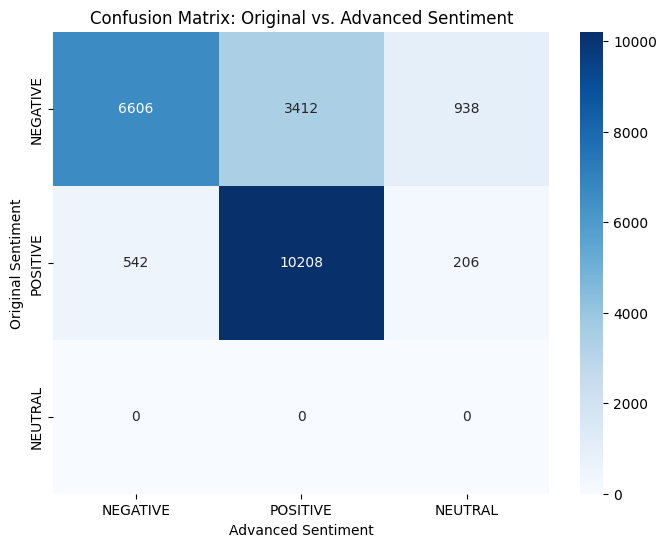

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

if 'comparison_df' in locals() and not comparison_df.empty:
    # Map sentiments to a consistent numerical format for metrics calculation
    # Assuming 'POSITIVE': 1, 'NEGATIVE': 0, 'NEUTRAL': 2 for both original and advanced
    sentiment_map = {'POSITIVE': 1, 'NEGATIVE': 0, 'NEUTRAL': 2}

    # Ensure both columns are mapped. Handle potential 'ERROR' labels if any were generated.
    comparison_df_filtered = comparison_df[comparison_df['advanced_sentiment'] != 'ERROR'].copy()

    # Convert sentiment labels to numerical values
    y_true = comparison_df_filtered['original_sentiment'].map(sentiment_map)
    y_pred = comparison_df_filtered['advanced_sentiment'].map(sentiment_map)

    # Filter out rows where mapping resulted in NaN (if 'NEUTRAL' was not always present in both)
    y_true_final = y_true.dropna()
    y_pred_final = y_pred.dropna()

    # Ensure both series have the same index after dropping NaNs
    common_index = y_true_final.index.intersection(y_pred_final.index)
    y_true_final = y_true_final.loc[common_index]
    y_pred_final = y_pred_final.loc[common_index]

    if not y_true_final.empty and not y_pred_final.empty:
        # Calculate Accuracy
        accuracy = accuracy_score(y_true_final, y_pred_final)
        print(f"\nOverall Accuracy between Original and Advanced Sentiments: {accuracy:.4f}")

        # Generate Classification Report
        # Need to reconstruct target_names based on actual labels present after mapping
        target_names_set = set(comparison_df_filtered['original_sentiment']).union(set(comparison_df_filtered['advanced_sentiment']))
        if 'ERROR' in target_names_set:
            target_names_set.remove('ERROR') # Remove ERROR from target names for classification report

        # Create a sorted list of unique labels present in the filtered data
        actual_labels = sorted([label for label in sentiment_map if label in target_names_set], key=lambda x: sentiment_map[x])

        print("\nClassification Report (Original vs. Advanced Sentiments):")
        print(classification_report(y_true_final, y_pred_final, target_names=actual_labels, zero_division=0))

        # Generate Confusion Matrix
        conf_matrix = confusion_matrix(y_true_final, y_pred_final)
        print("\nConfusion Matrix (Original vs. Advanced Sentiments):")
        print(conf_matrix)

        # Plot Confusion Matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=actual_labels, yticklabels=actual_labels)
        plt.title('Confusion Matrix: Original vs. Advanced Sentiment')
        plt.xlabel('Advanced Sentiment')
        plt.ylabel('Original Sentiment')
        plt.show()
    else:
        print("Not enough data to calculate metrics after filtering for valid sentiments.")
else:
    print("The 'comparison_df' is not available or is empty. Please ensure the comparison cell was run.")

### Aspects with Most Disagreement

To understand where the two models (original ABSA and advanced zero-shot ABSA) diverge the most, let's count the occurrences of each aspect in the `disagreements` DataFrame. This will show us which aspects are most frequently interpreted differently by the two sentiment analysis approaches.

Aspects with the most disagreement between Original and Advanced Sentiment:


,count
aspect,
product,17
performance,13
battery,11
macbook,9
value,9
display,6
price,6
screen,6
battery life,4


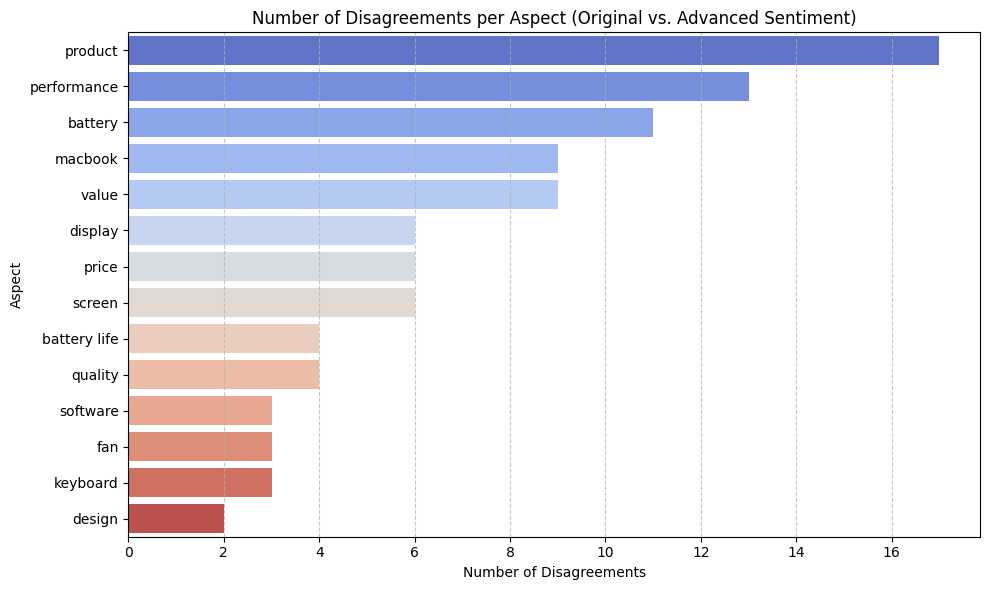

In [47]:
if 'disagreements' in locals() and not disagreements.empty:
    disagreement_counts_by_aspect = disagreements['aspect'].value_counts()
    print("Aspects with the most disagreement between Original and Advanced Sentiment:")
    display(disagreement_counts_by_aspect)

    # Optionally, visualize this
    plt.figure(figsize=(10, 6))
    sns.barplot(x=disagreement_counts_by_aspect.values, y=disagreement_counts_by_aspect.index, palette='coolwarm', hue=disagreement_counts_by_aspect.index, legend=False)
    plt.title('Number of Disagreements per Aspect (Original vs. Advanced Sentiment)')
    plt.xlabel('Number of Disagreements')
    plt.ylabel('Aspect')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("The 'disagreements' DataFrame is not available or is empty. Cannot analyze disagreement by aspect.")


Analysis of Disagreements for Original 'NEGATIVE' Sentiments:
How advanced sentiment reclassified original 'NEGATIVE' reviews:


,count
advanced_sentiment,
POSITIVE,3412
NEUTRAL,938



Top aspects contributing to disagreements for original 'NEGATIVE' sentiments:


,count
aspect,
product,802
battery,734
performance,575
value,390
display,381
price,308
quality,292
keyboard,171
design,158


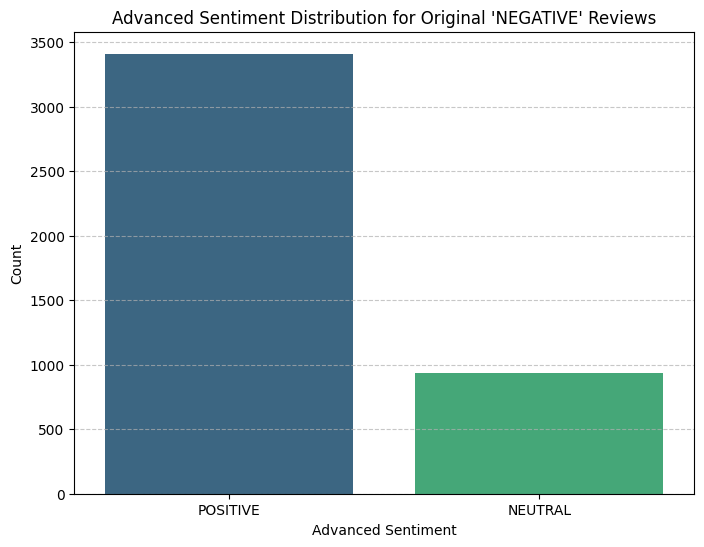


Sample reviews where original sentiment was 'NEGATIVE' but advanced sentiment disagreed (first 5):


,review_id,aspect,relevant_sentence,original_sentiment,original_score,advanced_sentiment,advanced_score
10956,2,product,origional product,NEGATIVE,0.979259,POSITIVE,0.664156
10957,4,software,"as a software developer, i installed intellij ...",NEGATIVE,0.999009,POSITIVE,0.847355
10958,14,product,and i must say no one can match apple product,NEGATIVE,0.999760,POSITIVE,0.684545
10961,20,screen,especially the screen corners are so thin with...,NEGATIVE,0.999571,POSITIVE,0.680457
10962,29,performance,the performance it delivers is just unmatched,NEGATIVE,0.992095,POSITIVE,0.984363


In [33]:
if 'disagreements' in locals() and not disagreements.empty:
    # Filter for disagreements where the original sentiment was NEGATIVE
    negative_disagreements = disagreements[disagreements['original_sentiment'] == 'NEGATIVE'].copy()

    if not negative_disagreements.empty:
        print("\nAnalysis of Disagreements for Original 'NEGATIVE' Sentiments:")
        print("How advanced sentiment reclassified original 'NEGATIVE' reviews:")
        display(negative_disagreements['advanced_sentiment'].value_counts())

        print("\nTop aspects contributing to disagreements for original 'NEGATIVE' sentiments:")
        disagreement_aspects_negative = negative_disagreements['aspect'].value_counts()
        display(disagreement_aspects_negative.head(10))

        # Visualize the distribution of advanced sentiments for original 'NEGATIVE' reviews
        plt.figure(figsize=(8, 6))
        sns.countplot(x='advanced_sentiment', data=negative_disagreements, palette='viridis', hue='advanced_sentiment', legend=False)
        plt.title("Advanced Sentiment Distribution for Original 'NEGATIVE' Reviews")
        plt.xlabel('Advanced Sentiment')
        plt.ylabel('Count')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

        # Display some sample reviews from the disagreements where original was NEGATIVE
        print("\nSample reviews where original sentiment was 'NEGATIVE' but advanced sentiment disagreed (first 5):")
        display(negative_disagreements.head())

    else:
        print("No disagreements found where the original sentiment was 'NEGATIVE'.")
else:
    print("The 'disagreements' DataFrame is not available or is empty. Cannot analyze disagreement by aspect.")

### Cross-Tabulation of Original vs. Advanced Zero-Shot Sentiments

To get a deeper understanding of the agreement and disagreement between the two models, let's create a cross-tabulation of their predicted sentiments. This will show us the frequency of each sentiment combination (e.g., how many times 'Original: POSITIVE' and 'Advanced: NEGATIVE'). This is particularly useful for identifying systematic biases or differences in how each model interprets sentiment for various aspects.

You now have your data split into `X_train`, `X_val`, `X_test` (features) and `y_train`, `y_val`, `y_test` (encoded sentiment labels).

**Next Steps for building the ABSA model:**

1.  **Feature Vectorization**: Convert the text data (`relevant_sentence` and `aspect`) into numerical features that a machine learning model can understand. Common techniques include TF-IDF, Word2Vec, or pre-trained sentence embeddings (e.g., from BERT).
2.  **Model Selection and Training**: Choose a suitable classification model (e.g., Logistic Regression, Support Vector Machines, Random Forest, or more advanced neural networks) and train it on the `X_train` and `y_train` data.
3.  **Model Evaluation**: Evaluate the trained model's performance on the `X_test` and `y_test` data using metrics like accuracy, precision, recall, F1-score, and a confusion matrix. The validation set (`X_val`, `y_val`) would be used for hyperparameter tuning during model development.

Cross-Tabulation of Original Sentiment vs. Advanced Zero-Shot Sentiment:


advanced_sentiment,NEGATIVE,NEUTRAL,POSITIVE
original_sentiment,,,
NEGATIVE,6606,938,3412
POSITIVE,542,206,10208


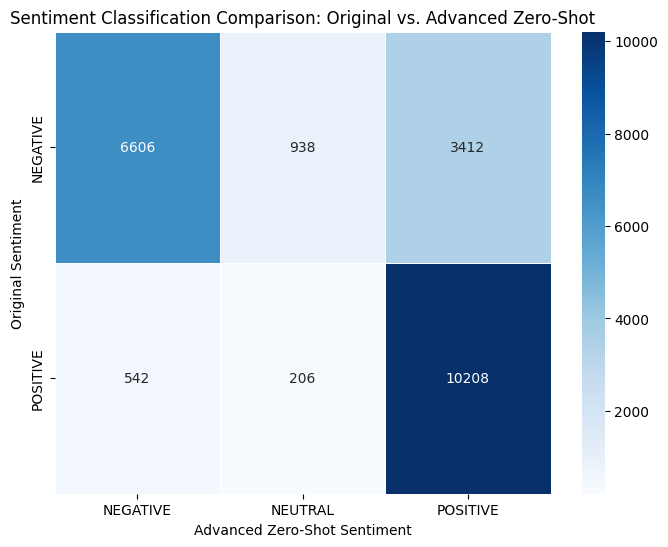

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if 'comparison_df' in locals() and not comparison_df.empty:
    # Create a cross-tabulation
    sentiment_crosstab = pd.crosstab(comparison_df['original_sentiment'], comparison_df['advanced_sentiment'])
    print("Cross-Tabulation of Original Sentiment vs. Advanced Zero-Shot Sentiment:")
    display(sentiment_crosstab)

    # Visualize the cross-tabulation as a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(sentiment_crosstab, annot=True, fmt='d', cmap='Blues', linewidths=.5)
    plt.title('Sentiment Classification Comparison: Original vs. Advanced Zero-Shot')
    plt.xlabel('Advanced Zero-Shot Sentiment')
    plt.ylabel('Original Sentiment')
    plt.show()

else:
    print("The 'comparison_df' is not available or is empty. Please ensure the comparison cell was run.")

### Saving the Trained Model and Results

It's crucial to save your trained machine learning model so you don't have to re-train it every time you want to use it. You can also save your processed data or comparison results for future analysis.

We will save the Logistic Regression model (`log_reg_model`) as it performed slightly better on the test set. We'll use `joblib` for this, which is efficient for scikit-learn models.

In [34]:
import joblib
import os

# Define a directory to save models and results
output_dir = '/content/drive/My Drive/TechLabs_2026/models/'
os.makedirs(output_dir, exist_ok=True)

# Save the Logistic Regression model
model_filename = os.path.join(output_dir, 'logistic_regression_model.joblib')
joblib.dump(log_reg_model, model_filename)
print(f"Logistic Regression model saved to: {model_filename}")

# Save the TF-IDF Vectorizer (important for consistent preprocessing)
vectorizer_filename = os.path.join(output_dir, 'tfidf_vectorizer.joblib')
joblib.dump(tfidf_vectorizer, vectorizer_filename)
print(f"TF-IDF Vectorizer saved to: {vectorizer_filename}")

# Save the Label Encoder
label_encoder_filename = os.path.join(output_dir, 'label_encoder.joblib')
joblib.dump(label_encoder, label_encoder_filename)
print(f"Label Encoder saved to: {label_encoder_filename}")

Logistic Regression model saved to: /content/drive/My Drive/TechLabs_2026/models/logistic_regression_model.joblib
TF-IDF Vectorizer saved to: /content/drive/My Drive/TechLabs_2026/models/tfidf_vectorizer.joblib
Label Encoder saved to: /content/drive/My Drive/TechLabs_2026/models/label_encoder.joblib


You might also want to save the `comparison_df` to a CSV for external analysis or record-keeping.

In [35]:
import os

# Ensure output directory exists
output_dir_data = '/content/drive/My Drive/TechLabs_2026/data_outputs/'
os.makedirs(output_dir_data, exist_ok=True)

# Save the comparison_df
comparison_output_path = os.path.join(output_dir_data, 'sentiment_comparison_results.csv')
if 'comparison_df' in locals() and not comparison_df.empty:
    comparison_df.to_csv(comparison_output_path, index=False)
    print(f"Comparison DataFrame saved to: {comparison_output_path}")
else:
    print("comparison_df is not available or empty, cannot save.")

Comparison DataFrame saved to: /content/drive/My Drive/TechLabs_2026/data_outputs/sentiment_comparison_results.csv


### Model Serving

Serving a machine learning model involves making it accessible for real-time predictions or batch processing in an application. Since you previously removed FastAPI deployment, here are some common ways to serve your model, ranging from simple to more robust solutions:

1.  **Local API with Flask/FastAPI (as previously explored):**
    *   You could re-implement a small API using Flask or FastAPI that loads your saved model and vectorizer, takes new review text as input, preprocesses it, makes a prediction, and returns the sentiment. This is great for local testing or small-scale applications.

2.  **Cloud-based Machine Learning Platforms:**
    *   **Google Cloud Vertex AI (or equivalent AWS SageMaker, Azure ML):** These platforms provide robust infrastructure for deploying models as managed endpoints. You can upload your saved model (`.joblib` file) and define a prediction routine. This handles scaling, monitoring, and integration with other cloud services.

3.  **Docker Containers:**
    *   Containerize your application (including your model, code, and dependencies) using Docker. This creates a portable and reproducible environment for deployment on various platforms (e.g., Kubernetes, Cloud Run, EC2).

4.  **Batch Predictions:**
    *   If real-time predictions aren't strictly necessary, you can load your model and vectorizer, process new data in batches, and save the predictions. This is simpler than setting up an API.

To serve your model for real-time predictions, you would typically:
1.  **Load the saved `tfidf_vectorizer` and `logistic_regression_model`**.
2.  **Receive new input text** (e.g., a new product review).
3.  **Clean and preprocess the input text** using the `clean_text` function.
4.  **Extract aspects** using the `extract_aspects_cleaned` function.
5.  For each aspect, form the `relevant_sentence` and combine it with the aspect.
6.  **Transform the combined text** using the loaded `tfidf_vectorizer`.
7.  **Predict the sentiment** using the loaded `logistic_regression_model`.
8.  **Convert the numerical prediction back to a sentiment label** using the loaded `label_encoder`.
9.  **Return the prediction**.

### Free and Low-Cost Model Serving Options

1.  **Local API with Flask/FastAPI**: This is often the *freest* option as it runs on your local machine or a low-cost virtual private server (VPS). You write a small web application (e.g., using Flask or FastAPI) that exposes an endpoint. When a request comes in, it loads your model, makes a prediction, and returns the result.
    *   **Pros**: Complete control, no cloud vendor lock-in, free infrastructure if running locally.
    *   **Cons**: Requires managing your own server, scaling can be complex, not ideal for high-traffic production without significant engineering.

2.  **Hugging Face Spaces / Streamlit Sharing**: If your goal is to showcase your model with an interactive demo, platforms like [Hugging Face Spaces](https://huggingface.co/spaces) and [Streamlit Sharing](https://streamlit.io/cloud) offer free tiers for deploying web applications built with their libraries. You can integrate your model into a Streamlit or Gradio app and deploy it for free.
    *   **Pros**: Easy deployment of interactive demos, often free, integrated with popular ML libraries.
    *   **Cons**: Primarily for demos, limited computational resources on free tiers, not suited for complex backend logic or high-throughput APIs.

3.  **Cloud Free Tiers (e.g., Google Cloud Run, AWS Lambda with API Gateway)**: Major cloud providers offer free tiers that can host small-scale model serving. You would typically deploy your model as a serverless function (like AWS Lambda or Google Cloud Functions) or containerized service (like Google Cloud Run). For very low traffic, these can remain within the free tier limits.
    *   **Pros**: Scalable, managed infrastructure, integration with other cloud services, cost-effective for low usage.
    *   **Cons**: Can incur costs if usage exceeds free tier, requires some cloud knowledge, potentially more complex setup than local APIs.

Let's set up a basic Flask application to demonstrate how you could serve your Logistic Regression model locally. This example will show you how to load your saved model components and make predictions.

In [36]:
import joblib
import os
from flask import Flask, request, jsonify
import pandas as pd
import re

# --- 1. Load Saved Model Components ---
output_dir = '/content/drive/My Drive/TechLabs_2026/models/'

# Check if the model files exist before attempting to load
model_path = os.path.join(output_dir, 'logistic_regression_model.joblib')
vectorizer_path = os.path.join(output_dir, 'tfidf_vectorizer.joblib')
label_encoder_path = os.path.join(output_dir, 'label_encoder.joblib')

if os.path.exists(model_path) and os.path.exists(vectorizer_path) and os.path.exists(label_encoder_path):
    log_reg_model = joblib.load(model_path)
    tfidf_vectorizer = joblib.load(vectorizer_path)
    label_encoder = joblib.load(label_encoder_path)
    print("Model, vectorizer, and label encoder loaded successfully.")
else:
    print("Error: One or more model files not found. Please ensure they are saved in the correct directory.")
    # Exit or handle the error appropriately if files are missing
    exit()

# --- 2. Define Preprocessing Functions (same as used during training) ---
common_laptop_aspects = [
    "screen", "display", "battery", "battery life", "performance", "speed",
    "keyboard", "trackpad", "design", "build quality", "price", "fan", "speakers",
    "product", "camera", "software", "macbook", "quality", "value"
]

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    allowed_chars = set('abcdefghijklmnopqrstuvwxyz0123456789 .,!?')
    cleaned_chars = [char for char in text if char in allowed_chars or char.isspace()]
    cleaned_text = "".join(cleaned_chars)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    return cleaned_text

def extract_aspects_cleaned(review_text, aspects_list):
    found_aspects = []
    if not isinstance(review_text, str):
        return []
    review_lower = review_text.lower()
    for aspect in aspects_list:
        if aspect in review_lower:
            found_aspects.append(aspect)
    return list(set(found_aspects))

# --- 3. Create Flask App ---
app = Flask(__name__)

@app.route('/predict_sentiment', methods=['POST'])
def predict_sentiment():
    if not request.json or 'review' not in request.json:
        return jsonify({'error': 'Please provide a review in JSON format'}), 400

    review_text = request.json['review']

    # Preprocess the review
    cleaned_review = clean_text(review_text)
    extracted_aspects = extract_aspects_cleaned(cleaned_review, common_laptop_aspects)

    if not extracted_aspects:
        return jsonify({'message': 'No relevant aspects found in the review.', 'review': review_text}), 200

    predictions = []
    for aspect in extracted_aspects:
        # Form the relevant sentence (simplified for API, could be improved)
        # For a full serving solution, you'd want to re-implement the original sentence extraction logic
        relevant_sentence = cleaned_review # Use the whole cleaned review as context for simplicity in API

        combined_text = relevant_sentence + ' ' + aspect
        text_tfidf = tfidf_vectorizer.transform([combined_text])
        predicted_label_encoded = log_reg_model.predict(text_tfidf)
        predicted_sentiment = label_encoder.inverse_transform(predicted_label_encoded)[0]

        predictions.append({
            'aspect': aspect,
            'predicted_sentiment': predicted_sentiment
        })

    return jsonify({
        'review_original': review_text,
        'review_cleaned': cleaned_review,
        'predictions': predictions
    }), 200

# To run this Flask app in Colab, you would typically use ngrok or a similar tool to expose it.
# Alternatively, for local testing, you can run it from your terminal.

# Example of how you would run it (uncomment and run in a separate cell if you wish to test):
# if __name__ == '__main__':
#     # In Colab, you might need to use a tool like ngrok to expose the port
#     # !pip install flask-ngrok
#     # from flask_ngrok import run_with_ngrok
#     # run_with_ngrok(app)
#     app.run(port=5000)

print("Flask application setup. To run, execute `app.run()` in a new cell (or use ngrok for external access).")

Model, vectorizer, and label encoder loaded successfully.
Flask application setup. To run, execute `app.run()` in a new cell (or use ngrok for external access).


#### How to Test the Flask API (Local in Colab)

To test this Flask application within Google Colab, you generally need to expose the local server to the internet, which can be done using a service like `ngrok`.

1.  **Install `flask-ngrok`**: Run `!pip install flask-ngrok` in a new cell.
2.  **Modify the `if __name__ == '__main__':` block**: Uncomment and use `run_with_ngrok(app)` followed by `app.run()`.

**Example of a POST request (from a new Colab cell or your local machine):**

```python
import requests

# Replace with your ngrok URL if using ngrok, or localhost:5000 if running locally
# If running in Colab with ngrok, you'll get a URL like 'https://xxxx-xx-xxx-xxx-xx.ngrok-free.app'
# You can find the ngrok URL in the output of the cell where you run app.run_with_ngrok()
url = 'http://127.0.0.1:5000/predict_sentiment' # Default local URL

headers = {'Content-Type': 'application/json'}
data = {'review': 'The battery life is excellent but the keyboard feels cheap.'}

response = requests.post(url, json=data, headers=headers)
print(response.json())
```

This setup provides a foundational, free way to turn your trained model into an accessible service. For production use, you would move to more robust solutions like cloud-managed services or Docker containers.

In [37]:
# Install flask-ngrok to expose the local Flask server
!pip install flask-ngrok

In [ ]:
from flask_ngrok import run_with_ngrok

# Run the Flask app with ngrok
# This will provide a public URL to access your API
run_with_ngrok(app)
app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-7:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
            

Once the above cell runs, it will output an `ngrok` URL (e.g., `https://xxxx-xx-xxx-xxx-xx.ngrok-free.app`). You can then use this URL to send POST requests to your `/predict_sentiment` endpoint from a new Colab cell or any external tool.

In [ ]:
import requests

# !!! IMPORTANT: Replace 'YOUR_NGROK_URL' with the actual URL from the output of the previous cell !!!
# Example: url = 'https://xxxx-xx-xxx-xxx-xx.ngrok-free.app/predict_sentiment'
url = 'YOUR_NGROK_URL/predict_sentiment'

headers = {'Content-Type': 'application/json'}
data = {'review': 'The battery life is excellent but the keyboard feels cheap.'}

try:
    response = requests.post(url, json=data, headers=headers)
    response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
    print(response.json())
except requests.exceptions.RequestException as e:
    print(f"Error making request: {e}")
    print("Please ensure the ngrok server is running and the URL is correct.")


In [27]:
import pandas as pd

if 'df_absa_balanced' in locals() and not df_absa_balanced.empty and \
   'df_absa_advanced' in locals() and not df_absa_advanced.empty:

    # Select relevant columns for comparison from df_absa_balanced (original sentiment)
    original_sentiment_df = df_absa_balanced[['review_id', 'aspect', 'relevant_sentence', 'sentiment', 'score']].copy()
    original_sentiment_df.rename(columns={'sentiment': 'original_sentiment', 'score': 'original_score'}, inplace=True);

    # Select relevant columns for comparison from df_absa_advanced (advanced sentiment)
    advanced_sentiment_df = df_absa_advanced[['review_id', 'aspect', 'relevant_sentence', 'advanced_sentiment', 'advanced_score']].copy()

    # Merge the two DataFrames on common identifiers (review_id, aspect, relevant_sentence)
    comparison_df = pd.merge(original_sentiment_df, advanced_sentiment_df,
                             on=['review_id', 'aspect', 'relevant_sentence'],
                             how='left', suffixes=('_original', '_advanced'))

    print("Comparison Table (Original ABSA vs. Advanced Zero-Shot ABSA):")
    display(comparison_df.head(10))

    # Analyze agreement/disagreement
    agreement = (comparison_df['original_sentiment'] == comparison_df['advanced_sentiment']).sum()
    total_comparisons = len(comparison_df)
    print(f"\nTotal comparisons: {total_comparisons}")
    print(f"Agreement between original and advanced sentiment: {agreement} ({agreement/total_comparisons:.2%})")

    # Show cases where they disagree
    disagreements = comparison_df[comparison_df['original_sentiment'] != comparison_df['advanced_sentiment']]
    if not disagreements.empty:
        print("\nDisagreements between Original and Advanced Sentiment (first 5):")
        display(disagreements.head())
    else:
        print("\nNo disagreements found between original and advanced sentiment.")

else:
    print("One or both of df_absa_balanced or df_absa_advanced DataFrames are not available or are empty.")

One or both of df_absa_balanced or df_absa_advanced DataFrames are not available or are empty.


In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if 'comparison_df' in locals() and not comparison_df.empty:
    # Create a cross-tabulation
    sentiment_crosstab = pd.crosstab(comparison_df['original_sentiment'], comparison_df['advanced_sentiment'])
    print("Cross-Tabulation of Original Sentiment vs. Advanced Zero-Shot Sentiment:")
    display(sentiment_crosstab)

    # Visualize the cross-tabulation as a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(sentiment_crosstab, annot=True, fmt='d', cmap='Blues', linewidths=.5)
    plt.title('Sentiment Classification Comparison: Original vs. Advanced Zero-Shot')
    plt.xlabel('Advanced Zero-Shot Sentiment')
    plt.ylabel('Original Sentiment')
    plt.show()

else:
    print("The 'comparison_df' is not available or is empty. Please ensure the comparison cell was run.")

The 'comparison_df' is not available or is empty. Please ensure the comparison cell was run.


Now that the text has been cleaned, we should re-run the Aspect Term Extraction and Aspect Sentiment Classification steps using the `cleaned_review_text` column. I will prepare these cells for you.

In [59]:
# Re-applying Aspect Term Extraction on the full, cleaned, and augmented text

# Define aspects relevant to your dataset (you might want to customize this)
common_laptop_aspects = [
    "screen", "display", "battery", "battery life", "performance", "speed",
    "keyboard", "trackpad", "design", "build quality", "price", "fan", "speakers",
    "product", "camera", "software", "macbook", "quality", "value"
]

def extract_aspects_cleaned(review_text, aspects_list):
    found_aspects = []
    if not isinstance(review_text, str):
        return []
    review_lower = review_text.lower()
    for aspect in aspects_list:
        if aspect in review_lower:
            found_aspects.append(aspect)
    return list(set(found_aspects)) # Return unique aspects

# Apply aspect extraction to your augmented DataFrame using the cleaned text
if 'df_augmented_full' in locals() and not df_augmented_full.empty and 'cleaned_review_text' in df_augmented_full.columns:
    df_augmented_full['extracted_aspects'] = df_augmented_full['cleaned_review_text'].apply(lambda x: extract_aspects_cleaned(x, common_laptop_aspects))
    print(f"Extracted aspects for {len(df_augmented_full)} reviews using cleaned text.")
    print("First 5 reviews with cleaned text and extracted aspects:")
    display(df_augmented_full[['cleaned_review_text', 'extracted_aspects']].head())
else:
    print("DataFrame 'df_augmented_full' or 'cleaned_review_text' column not found. Please check previous steps.")

DataFrame 'df_augmented_full' or 'cleaned_review_text' column not found. Please check previous steps.


In [60]:
from transformers import pipeline
import pandas as pd

# Initialize a sentiment analysis pipeline (re-initialize if not in scope or for fresh start)
classifier = pipeline('sentiment-analysis')

absa_results_full = []

if 'df_augmented_full' in locals() and not df_augmented_full.empty and 'extracted_aspects' in df_augmented_full.columns:
    # Process the ENTIRE df_augmented_full DataFrame
    df_to_process = df_augmented_full

    print(f"Performing Aspect Sentiment Classification on {len(df_to_process)} reviews from the augmented dataset...")
    # Iterate over rows with iterrows() for access to index and row data
    for idx, row in df_to_process.iterrows():
        review_text_cleaned = row['cleaned_review_text']
        review_aspects = row['extracted_aspects']

        if not review_aspects:
            continue

        for aspect in review_aspects:
            # Simple context extraction: try to get the sentence containing the aspect.
            sentences = review_text_cleaned.split('.') # Basic sentence splitting
            relevant_sentence = ''
            for s in sentences:
                if aspect in s.lower():
                    relevant_sentence = s.strip()
                    break

            if relevant_sentence:
                try:
                    sentiment_output = classifier(relevant_sentence)
                    sentiment = sentiment_output[0]['label']
                    score = sentiment_output[0]['score']
                    absa_results_full.append({
                        'review_id': idx, # Using original DataFrame index as review_id
                        'review_text_original': row['review_text'], # Keep original for context
                        'review_text_cleaned': review_text_cleaned,
                        'aspect': aspect,
                        'relevant_sentence': relevant_sentence,
                        'sentiment': sentiment,
                        'score': score
                    })
                except Exception as e:
                    print(f"Error processing review {idx}, aspect '{aspect}': {e}")
            # else: No clear context found for this aspect, skip for sentiment analysis

    if absa_results_full:
        df_absa_full = pd.DataFrame(absa_results_full)
        print("\nABSA Results DataFrame (after cleaning and full augmentation):")
        display(df_absa_full.head())
        print(f"Generated ABSA results for {len(df_absa_full)} aspect-sentiment pairs from the full augmented dataset.")
    else:
        print("No ABSA results generated for the full augmented data. Check if aspects were extracted or reviews processed.")
        df_absa_full = pd.DataFrame() # Ensure df_absa_full is defined even if no results
else:
    print("DataFrame 'df_augmented_full' or 'extracted_aspects' column not found. Please check previous steps.")
    df_absa_full = pd.DataFrame() # Ensure df_absa_full is defined even if df is not available

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DataFrame 'df_augmented_full' or 'extracted_aspects' column not found. Please check previous steps.
